# IEC 61850 Anomaly Detection — Optimized Models

Clean, paper-ready notebook. Each model is hyper-parameter-searched across multiple feature presets, then the **best configuration is re-trained** to produce publication-quality charts.

| § | Model | Type |
|---|-------|------|
| 3 | Random Forest | Supervised classification |
| 4 | MLP Autoencoder | Unsupervised point-wise reconstruction |
| 5 | LSTM Autoencoder | Sequential reconstruction (encoder–decoder) |
| 6 | RNN Autoencoder | Sequential reconstruction (encoder–decoder) |
| 7 | GRU Autoencoder | Sequential reconstruction (encoder–decoder) |
| 8 | Model Comparison | Cross-model metrics + latency |

In [53]:
import os, time, itertools, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve,
)
from tqdm.auto import tqdm

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Publication-quality plot style ────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        120,
    'savefig.dpi':       300,
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
    'figure.titlesize':  15,
    'legend.framealpha': 0.8,
    'axes.grid':         True,
    'grid.alpha':        0.3,
})
PALETTE = {'normal': '#4878CF', 'attack': '#D65F5F', 'threshold': '#2C2C2C'}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}  |  Device: {device}')

PyTorch 2.6.0+cu118  |  Device: cuda


## Label Class Distribution

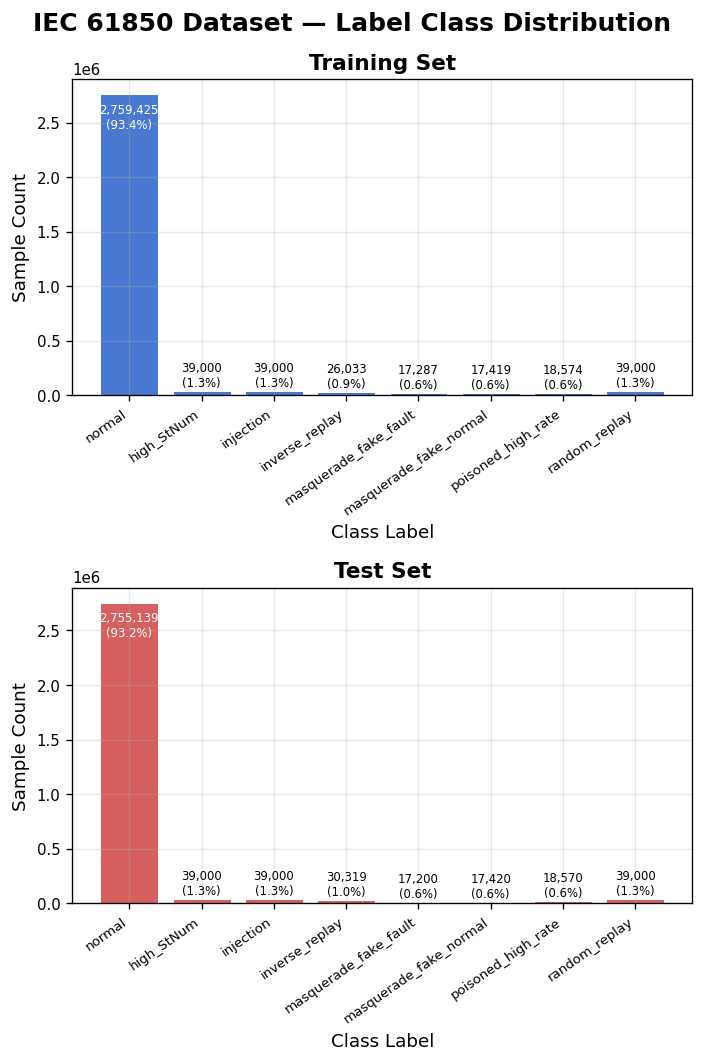


Training set counts:
  normal                    2,759,425  (93.36%)
  high_StNum                  39,000  (1.32%)
  injection                   39,000  (1.32%)
  inverse_replay              26,033  (0.88%)
  masquerade_fake_fault       17,287  (0.58%)
  masquerade_fake_normal      17,419  (0.59%)
  poisoned_high_rate          18,574  (0.63%)
  random_replay               39,000  (1.32%)

Test set counts:
  normal                    2,755,139  (93.22%)
  high_StNum                  39,000  (1.32%)
  injection                   39,000  (1.32%)
  inverse_replay              30,319  (1.03%)
  masquerade_fake_fault       17,200  (0.58%)
  masquerade_fake_normal      17,420  (0.59%)
  poisoned_high_rate          18,570  (0.63%)
  random_replay               39,000  (1.32%)


In [54]:

# ── Label class distribution ───────────────────────────────────────────────────
train_counts  = train_df[LABEL_COL].value_counts().sort_index()
test_counts   = test_df[LABEL_COL].value_counts().sort_index()
other_classes = sorted(c for c in set(train_counts.index) | set(test_counts.index) if c != 'normal')
all_classes   = ['normal'] + other_classes
train_vals    = [train_counts.get(c, 0) for c in all_classes]
test_vals     = [test_counts.get(c, 0)  for c in all_classes]

x      = np.arange(len(all_classes))
width  = 0.35
colors = ['#4878CF', '#D65F5F']

fig, axes = plt.subplots(2, 1, figsize=(6, 9))
fig.suptitle('IEC 61850 Dataset — Label Class Distribution', fontweight='bold')

for ax, vals, title, color in zip(
    axes,
    [train_vals, test_vals],
    ['Training Set', 'Test Set'],
    colors,
):
    bars = ax.bar(x, vals, color=color, edgecolor='white', linewidth=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(all_classes, rotation=35, ha='right', fontsize=8)
    ax.set_title(title)
    ax.set_xlabel('Class Label')
    ax.set_ylabel('Sample Count')
    total = sum(vals)
    max_v = max(vals)
    for bar, v in zip(bars, vals):
        # Place label inside the bar if it's very tall (normal class),
        # otherwise place it above
        if v > max_v * 0.5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                v * 0.97,
                f'{v:,}\n({v/total*100:.1f}%)',
                ha='center', va='top', fontsize=7, color='white',
            )
        else:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + total * 0.005,
                f'{v:,}\n({v/total*100:.1f}%)',
                ha='center', va='bottom', fontsize=7, color='black',
            )

plt.tight_layout()
plt.show()

print("\nTraining set counts:")
for cls, cnt in zip(all_classes, train_vals):
    print(f"  {cls:<25} {cnt:>8,}  ({cnt/sum(train_vals)*100:.2f}%)")
print(f"\nTest set counts:")
for cls, cnt in zip(all_classes, test_vals):
    print(f"  {cls:<25} {cnt:>8,}  ({cnt/sum(test_vals)*100:.2f}%)")


## 1. Data Loading & Preprocessing

Download the ERENO IEC 61850 dataset, define column groups aligned with the IDS literature, and build the cleaned dataframes used by `prepare_data()` throughout the notebook.

In [55]:
COLUMNS = [
    'Time','isbA','isbB','isbC','ismA','ismB','ismC',
    'vsbA','vsbB','vsbC','vsmA','vsmB','vsmC',
    'isbARmsValue','isbBRmsValue','iisbCRmsValue',
    'ismARmsValue','ismBRmsValue','ismCRmsValue',
    'vsbARmsue','vsbBRmsValue','vsbCRmsValue',
    'vsmARmsValue','vsmBRmsValue','vsmCRmsValue',
    'isbATrapAreaSum','isbBTrapAreaSum','isbCTrapAreaSum',
    'ismATrapAreaSuValm','ismBTrapAreaSum','ismCTrapAreaSum',
    'vsbATrapAreaSum','vsbBTrapAreaSum','vsbCTrapAreaSum',
    'vsmATrapAreaSum','vsmBTrapAreaSum','vsmCTrapAreaSum',
    't','GooseTimestamp','SqNum','StNum','cbStatus','frameLen',
    'ethDst','ethSrc','ethType','gooseTimeAllowedtoLive',
    'gooseAppid','gooseLen','TPID','gocbRef','datSet','goID',
    'test','confRev','ndsCom','numDatSetEntries','APDUSize',
    'protocol','stDiff','sqDiff','gooseLengthDiff','cbStatusDiff',
    'apduSizeDiff','frameLengthDiff','timestampDiff',
    'tDiff','timeFromLastChange','delay','class',
]

# ── IEC 61850 column groups ────────────────────────────────────────────────────
SV_INSTANTANEOUS = [
    'isbA','isbB','isbC','ismA','ismB','ismC',
    'vsbA','vsbB','vsbC','vsmA','vsmB','vsmC',
]
DELTA_FEATURES = [
    'stDiff','sqDiff','gooseLengthDiff','cbStatusDiff',
    'apduSizeDiff','frameLengthDiff','timestampDiff',
    'tDiff','timeFromLastChange','delay',
]
# Table 6 from the IDS literature — original GOOSE protocol fields
GOOSE_PROTOCOL = [
    'frameLen','gooseLen','gooseTimeAllowedtoLive',
    't','StNum','SqNum','test','cbStatus','APDUSize',
]
# Table 7 from the IDS literature — derived delta features
DERIVED_LITERATURE = [
    'stDiff','sqDiff','gooseLengthDiff',
    'frameLengthDiff','timestampDiff','tDiff',
]

LABEL_COL = 'class'
KNOWN_CAT = ['test']   # only remaining potentially-categorical field

# Near-constant / identifier columns to drop before modeling
FEATURES_TO_DROP = [
    'Time','GooseTimestamp',
    'ethDst','ethSrc','ethType','TPID',
    'protocol','gocbRef','datSet','goID','gooseAppid',
    'confRev','ndsCom','numDatSetEntries',
]

# ── Download & load ────────────────────────────────────────────────────────────
data_path = kagglehub.dataset_download("sequincozes/ereno-iec61850-ids")
train_df  = pd.read_csv(os.path.join(data_path, "train.csv"),
                        sep=',', skiprows=1, header=None, names=COLUMNS)
test_df   = pd.read_csv(os.path.join(data_path, "test.csv"),
                        sep=',', skiprows=1, header=None, names=COLUMNS)

# ── Align columns ──────────────────────────────────────────────────────────────
train_df    = train_df.dropna(axis=1)
test_df     = test_df.dropna(axis=1)
shared_cols = [c for c in train_df.columns if c in test_df.columns]
train_df    = train_df[shared_cols]
test_df     = test_df[shared_cols]

# ── Encode labels ──────────────────────────────────────────────────────────────
le              = LabelEncoder()
y_train_raw     = le.fit_transform(train_df[LABEL_COL])
y_test_raw      = le.transform(test_df[LABEL_COL])
normal_cls_idx  = le.transform(['normal'])[0]
y_train_binary  = (y_train_raw != normal_cls_idx).astype(int)
y_test_binary   = (y_test_raw  != normal_cls_idx).astype(int)

print(f"train_df : {train_df.shape}   test_df : {test_df.shape}")
print(f"Classes  : {list(le.classes_)}")
print(f"Train  0/1 → {dict(pd.Series(y_train_binary).value_counts().sort_index())}")
print(f"Test   0/1 → {dict(pd.Series(y_test_binary).value_counts().sort_index())}")

train_df : (2955738, 70)   test_df : (2955648, 70)
Classes  : ['high_StNum', 'injection', 'inverse_replay', 'masquerade_fake_fault', 'masquerade_fake_normal', 'normal', 'poisoned_high_rate', 'random_replay']
Train  0/1 → {0: 2759425, 1: 196313}
Test   0/1 → {0: 2755139, 1: 200509}


## 2. Shared Infrastructure

Feature presets, `prepare_data()`, `SequenceDataset`, all model class definitions, evaluation utilities, and chart-helper functions used by every model section.

In [56]:
# ══════════════════════════════════════════════════════════════════════════════
# FEATURE PRESETS
# ══════════════════════════════════════════════════════════════════════════════
GOOSE_SURVIVING = [c for c in GOOSE_PROTOCOL if c in shared_cols]

FEATURE_PRESETS = {
    'all':            None,
    'goose_protocol': GOOSE_PROTOCOL,
    'goose_derived':  DERIVED_LITERATURE,
    'literature':     GOOSE_PROTOCOL + DERIVED_LITERATURE,
    'goose_full':     GOOSE_SURVIVING + DELTA_FEATURES,
    'goose_sv':       GOOSE_PROTOCOL + DERIVED_LITERATURE + SV_INSTANTANEOUS,
}

# Ordered list of presets evaluated in every model's feature-set sweep
SWEEP_PRESETS = ['goose_derived', 'literature', 'goose_sv']

_data_cache: dict   = {}
_loader_cache: dict = {}   # keyed by (preset, seq_len) — shared across all seq models

def prepare_data(preset: str = 'all'):
    """Return (X_tr, X_te, y_tr, y_te, feature_names) for a given preset. Cached."""
    if preset in _data_cache:
        return _data_cache[preset]

    X_tr = train_df.drop(columns=[LABEL_COL])
    X_te = test_df.drop(columns=[LABEL_COL])
    dc   = [c for c in FEATURES_TO_DROP if c in X_tr.columns]
    X_tr = X_tr.drop(columns=dc)
    X_te = X_te.drop(columns=dc)

    if FEATURE_PRESETS.get(preset) is not None:
        keep = [c for c in FEATURE_PRESETS[preset] if c in X_tr.columns]
        X_tr, X_te = X_tr[keep], X_te[keep]

    n_cols = [c for c in X_tr.select_dtypes(include=[np.number]).columns if c not in KNOWN_CAT]
    c_cols = list(set(X_tr.select_dtypes(include=['object']).columns.tolist() + KNOWN_CAT)
                  & set(X_tr.columns))

    sc = StandardScaler()
    X_tr[n_cols] = sc.fit_transform(X_tr[n_cols])
    X_te[n_cols] = sc.transform(X_te[n_cols])

    names = list(n_cols)
    if c_cols:
        enc     = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        tr_cat  = enc.fit_transform(X_tr[c_cols])
        te_cat  = enc.transform(X_te[c_cols])
        X_tr_np = np.hstack([X_tr[n_cols].values, tr_cat]).astype(np.float32)
        X_te_np = np.hstack([X_te[n_cols].values, te_cat]).astype(np.float32)
        names  += enc.get_feature_names_out(c_cols).tolist()
    else:
        X_tr_np = X_tr[n_cols].values.astype(np.float32)
        X_te_np = X_te[n_cols].values.astype(np.float32)

    result = (X_tr_np, X_te_np, y_train_binary, y_test_binary, names)
    _data_cache[preset] = result
    return result


# ══════════════════════════════════════════════════════════════════════════════
# SEQUENCE DATASET
# ══════════════════════════════════════════════════════════════════════════════
class SequenceDataset(Dataset):
    def __init__(self, X, y, seq_len, normal_only=False,
                 max_samples=None, seed=42, verbose=True):
        y_bin       = y.astype(np.uint8)
        attack      = (y_bin == 1)
        window_sums = np.convolve(attack, np.ones(seq_len, dtype=np.uint8), mode='valid')
        n_possible  = len(X) - seq_len
        valid_mask  = (window_sums[:n_possible] == 0) if normal_only \
                      else np.ones(n_possible, dtype=bool)
        indices = np.where(valid_mask)[0]
        if max_samples is not None and len(indices) > max_samples:
            rng     = np.random.default_rng(seed)
            indices = rng.choice(indices, size=max_samples, replace=False)
            indices.sort()
        idx_mat       = indices[:, None] + np.arange(seq_len, dtype=np.int64)
        self.y_labels = y_bin[idx_mat].any(axis=1).astype(np.uint8)
        self.X_seqs   = X[idx_mat].astype(np.float32)

    def __len__(self):   return len(self.X_seqs)
    def __getitem__(self, idx):
        seq = torch.from_numpy(self.X_seqs[idx])
        return seq[:-1], seq[1:]


def build_sequence_loaders(X_tr, y_tr, X_te, y_te,
                           seq_len=10, batch_size=512,
                           max_train=400_000, max_test=500_000):
    train_ds  = SequenceDataset(X_tr, y_tr, seq_len, normal_only=True,
                                max_samples=max_train, verbose=False)
    test_ds   = SequenceDataset(X_te, y_te, seq_len, normal_only=False,
                                max_samples=max_test,  verbose=False)
    train_ldr = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    test_ldr  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0)
    return train_ldr, test_ldr, test_ds.y_labels


# ══════════════════════════════════════════════════════════════════════════════
# MODEL CLASSES
# ══════════════════════════════════════════════════════════════════════════════
class LSTMAutoencoder(nn.Module):
    def __init__(self, in_f, hid, n_layers, drop):
        super().__init__()
        self.encoder = nn.LSTM(in_f, hid, n_layers, batch_first=True, dropout=drop)
        self.decoder = nn.LSTM(hid, hid, n_layers, batch_first=True, dropout=drop)
        self.proj    = nn.Linear(hid, in_f)
    def forward(self, x):
        _, (h, c) = self.encoder(x)
        rep = h[-1].unsqueeze(1).repeat(1, x.size(1), 1)
        out, _ = self.decoder(rep, (h, c))
        return self.proj(out)


class RNNAutoencoder(nn.Module):
    def __init__(self, in_f, hid, n_layers, drop):
        super().__init__()
        self.encoder = nn.RNN(in_f, hid, n_layers, batch_first=True,
                              dropout=drop, nonlinearity='tanh')
        self.decoder = nn.RNN(hid, hid, n_layers, batch_first=True,
                              dropout=drop, nonlinearity='tanh')
        self.proj    = nn.Linear(hid, in_f)
    def forward(self, x):
        _, h = self.encoder(x)
        rep  = h[-1].unsqueeze(1).repeat(1, x.size(1), 1)
        out, _ = self.decoder(rep, h)
        return self.proj(out)


class GRUAutoencoder(nn.Module):
    def __init__(self, in_f, hid, n_layers, drop):
        super().__init__()
        self.encoder = nn.GRU(in_f, hid, n_layers, batch_first=True, dropout=drop)
        self.decoder = nn.GRU(hid, hid, n_layers, batch_first=True, dropout=drop)
        self.proj    = nn.Linear(hid, in_f)
    def forward(self, x):
        _, h = self.encoder(x)
        rep  = h[-1].unsqueeze(1).repeat(1, x.size(1), 1)
        out, _ = self.decoder(rep, h)
        return self.proj(out)


def build_mlp_ae(in_dim: int, bottleneck: int) -> nn.Sequential:
    return nn.Sequential(
        nn.Linear(in_dim, 64),    nn.ReLU(),
        nn.Linear(64,     32),    nn.ReLU(),
        nn.Linear(32,     bottleneck), nn.ReLU(),
        nn.Linear(bottleneck, 32), nn.ReLU(),
        nn.Linear(32,     64),    nn.ReLU(),
        nn.Linear(64,     in_dim),
    )


# ══════════════════════════════════════════════════════════════════════════════
# TRAINING HELPERS
# ══════════════════════════════════════════════════════════════════════════════
def train_ae_flat(model, train_dl, n_epochs, lr, dev, desc='AE', patience=15):
    opt, crit = optim.Adam(model.parameters(), lr=lr), nn.MSELoss()
    scaler    = GradScaler('cuda', enabled=(dev.type == 'cuda'))
    losses, best_l, wait = [], float('inf'), 0
    for _ in tqdm(range(n_epochs), desc=desc, leave=False):
        model.train(); ep_loss = 0
        for X_in, X_out in train_dl:
            X_in, X_out = X_in.to(dev), X_out.to(dev)
            opt.zero_grad()
            with autocast('cuda', enabled=(dev.type == 'cuda')):
                loss = crit(model(X_in), X_out)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            ep_loss += loss.item()
        avg = ep_loss / len(train_dl); losses.append(avg)
        if avg < best_l - 1e-4: best_l, wait = avg, 0
        else:
            wait += 1
            if wait >= patience: break
    return losses


def train_seq_model(model, train_dl, n_epochs, lr, dev, desc='Model', patience=15):
    opt, crit = optim.Adam(model.parameters(), lr=lr), nn.MSELoss()
    scaler    = GradScaler('cuda', enabled=(dev.type == 'cuda'))
    losses, best_l, wait = [], float('inf'), 0
    for _ in tqdm(range(n_epochs), desc=desc, leave=False):
        model.train(); ep_loss = 0
        for X_in, X_out in train_dl:
            X_in, X_out = X_in.to(dev), X_out.to(dev)
            opt.zero_grad()
            with autocast('cuda', enabled=(dev.type == 'cuda')):
                loss = crit(model(X_in), X_out)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(opt); scaler.update()
            ep_loss += loss.item()
        avg = ep_loss / len(train_dl); losses.append(avg)
        if avg < best_l - 1e-4: best_l, wait = avg, 0
        else:
            wait += 1
            if wait >= patience: break
    return losses


# ══════════════════════════════════════════════════════════════════════════════
# EVALUATION & LATENCY UTILITIES
# ══════════════════════════════════════════════════════════════════════════════
def evaluate_classification(y_true, y_pred, y_score=None):
    m = {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        m['auc_roc'] = roc_auc_score(y_true, y_score)
    return m


def evaluate_ae_flat(model, X_te_t, y_te, dev, batch_size=512):
    model.eval(); errors = []
    with torch.no_grad():
        for i in range(0, len(X_te_t), batch_size):
            x   = X_te_t[i:i+batch_size].to(dev)
            err = ((x - model(x)) ** 2).mean(dim=1)
            errors.append(err.cpu().numpy())
    errors = np.concatenate(errors)
    fpr, tpr, thresholds = roc_curve(y_te, errors)
    opt_thr = thresholds[np.argmax(tpr - fpr)]
    y_pred  = (errors > opt_thr).astype(int)
    return evaluate_classification(y_te, y_pred, y_score=errors), y_pred, errors, opt_thr


def evaluate_seq_model(model, test_ldr, y_labels, dev):
    model.eval(); errors = []
    with torch.no_grad():
        for X_in, X_out in test_ldr:
            X_in, X_out = X_in.to(dev), X_out.to(dev)
            errors.append(((X_out - model(X_in)) ** 2).mean(dim=(1, 2)).cpu().numpy())
    errors = np.concatenate(errors)
    fpr, tpr, thresholds = roc_curve(y_labels, errors)
    opt_thr = thresholds[np.argmax(tpr - fpr)]
    y_pred  = (errors > opt_thr).astype(int)
    return evaluate_classification(y_labels, y_pred, y_score=errors), y_pred, errors, opt_thr


def measure_latency_sklearn(mdl, sample, n_runs=5000):
    sample = sample.reshape(1, -1)
    for _ in range(100): mdl.predict(sample)
    t0 = time.perf_counter()
    for _ in range(n_runs): mdl.predict(sample)
    return (time.perf_counter() - t0) / n_runs * 1000


def measure_latency_torch(mdl, sample, dev, n_runs=1000):
    mdl_cpu = mdl.cpu().eval(); s = sample.cpu()
    if s.dim() == 1: s = s.unsqueeze(0)
    with torch.no_grad():
        for _ in range(50): mdl_cpu(s)
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(n_runs): mdl_cpu(s)
    mdl.to(dev)
    return (time.perf_counter() - t0) / n_runs * 1000


# ══════════════════════════════════════════════════════════════════════════════
# CHART HELPERS
# ══════════════════════════════════════════════════════════════════════════════
def plot_roc(ax, fpr, tpr, auc_val, label='Model', color='steelblue'):
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{label}  (AUC = {auc_val:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve'); ax.legend(loc='lower right')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)


def plot_cm(ax, cm_arr, title='Confusion Matrix', cmap='Blues'):
    cm_norm = cm_arr.astype(float) / cm_arr.sum(axis=1, keepdims=True)
    annot   = np.array([[f'{v}\n({p:.1%})' for v, p in zip(rv, rp)]
                        for rv, rp in zip(cm_arr, cm_norm)])
    sns.heatmap(cm_arr, annot=annot, fmt='', cmap=cmap, ax=ax,
                xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'],
                linewidths=0.5, cbar=False)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title(title)


def plot_loss(ax, losses, title='Training Loss (MSE)'):
    ax.plot(losses, color='steelblue', lw=2)
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss'); ax.set_title(title)


def plot_error_dist(ax, errors, y_true, threshold, title='Reconstruction Error'):
    ax.hist(errors[y_true == 0], bins=100, alpha=0.6, label='Normal', color=PALETTE['normal'])
    ax.hist(errors[y_true == 1], bins=100, alpha=0.6, label='Attack', color=PALETTE['attack'])
    ax.axvline(threshold, color=PALETTE['threshold'], ls='--', lw=1.5,
               label=f'Threshold = {threshold:.4f}')
    ax.set_xlim(0, np.percentile(errors, 99))
    ax.set_xlabel('Reconstruction Error (MSE)'); ax.set_ylabel('Count')
    ax.set_title(title); ax.legend()


def plot_preset_sweep(ax, preset_metrics, best_preset, title):
    """Side-by-side F1 + AUC bars for each feature preset."""
    presets = list(preset_metrics.keys())
    x, w    = np.arange(len(presets)), 0.35
    f1s  = [preset_metrics[p]['f1']      for p in presets]
    aucs = [preset_metrics[p]['auc_roc'] for p in presets]
    cb   = ['#2ca02c' if p == best_preset else '#aec7e8' for p in presets]
    ca   = ['#1a7520' if p == best_preset else '#c6dbef' for p in presets]
    b1   = ax.bar(x - w/2, f1s,  w, color=cb, edgecolor='white', label='F1')
    ax.bar(x + w/2, aucs, w, color=ca,  edgecolor='white', label='AUC-ROC', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(presets, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel('Score')
    lo = max(0.0, min(f1s + aucs) - 0.05)
    ax.set_ylim(lo, 1.02)
    ax.set_title(title, fontweight='bold'); ax.legend(fontsize=9)
    for bar, v in zip(b1, f1s):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.003,
                f'{v:.3f}', ha='center', fontsize=7.5)


# ══════════════════════════════════════════════════════════════════════════════
# GLOBAL RESULTS DICT + CONSTANTS
# ══════════════════════════════════════════════════════════════════════════════
results     = {}
GOOSE_LIMIT = 4.0   # ms

print("Infrastructure ready.")
print(f"\nFeature preset dimensions:")
for p in SWEEP_PRESETS:
    X_tr, _, _, _, _ = prepare_data(p)
    print(f"  {p:16s}: {X_tr.shape[1]:3d} features")

Infrastructure ready.

Feature preset dimensions:
  goose_derived   :   6 features
  literature      :  16 features
  goose_sv        :  28 features


## 3. Random Forest

**Winner from capstone exploration:** `n_estimators=50`, `max_depth=None`, `min_samples_split=10`, `class_weight=balanced`

These fixed hyperparameters are evaluated across all **6 feature-set presets** to show which feature representation works best for a tree-based classifier.

Random Forest — feature-set sweep
  Fixed: n_estimators=50  max_depth=None  min_samples_split=10  class_weight=balanced

  Preset                 F1   AUC-ROC   Precision   Recall
  ──────────────────────────────────────────────────────────
  goose_derived      0.2788    0.7906      0.1781   0.6422
  literature         0.8922    0.9601      0.8727   0.9126
  goose_sv           0.9516    0.9937      0.9423   0.9612

★  Best preset: goose_sv  |  F1=0.9516  AUC=0.9937  Latency=21.837 ms

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00   2755139
      Attack       0.94      0.96      0.95    200509

    accuracy                           0.99   2955648
   macro avg       0.97      0.98      0.97   2955648
weighted avg       0.99      0.99      0.99   2955648



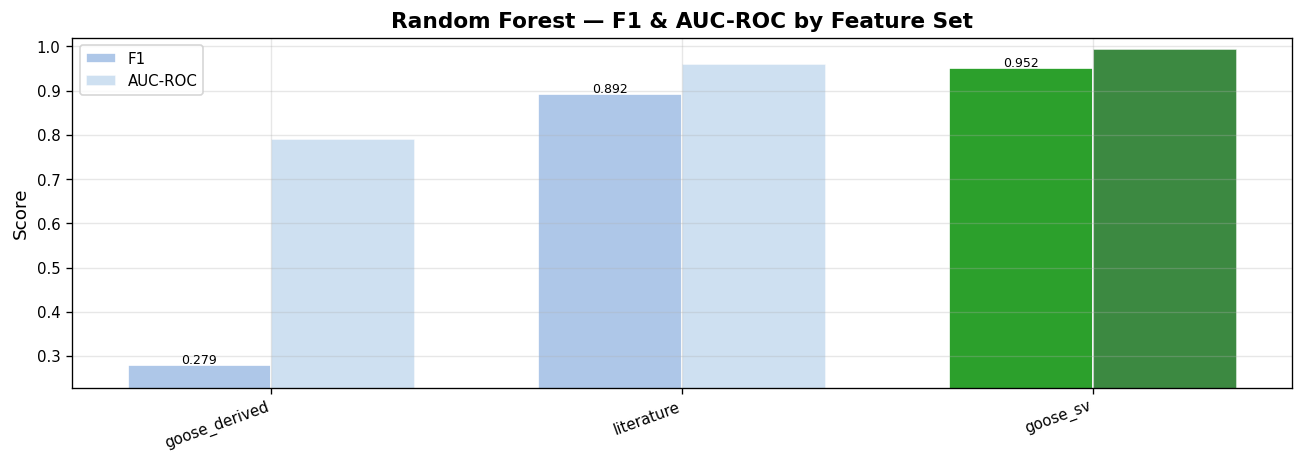

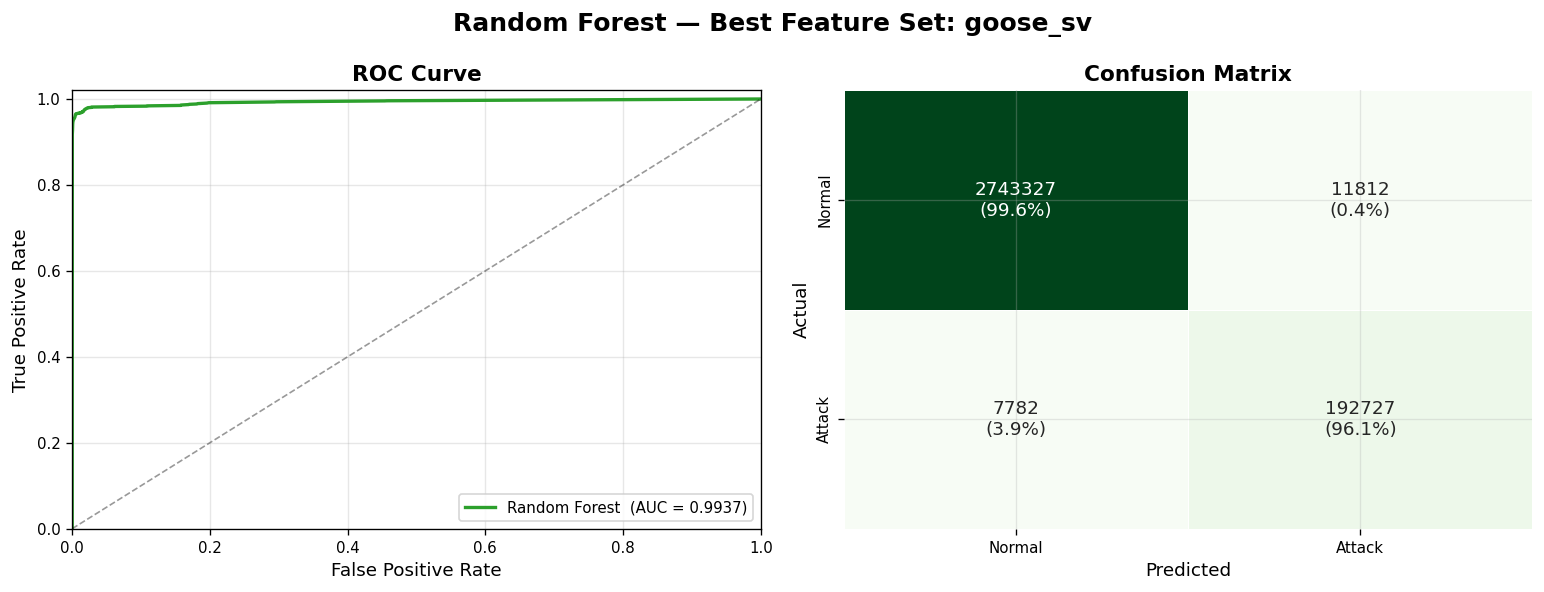

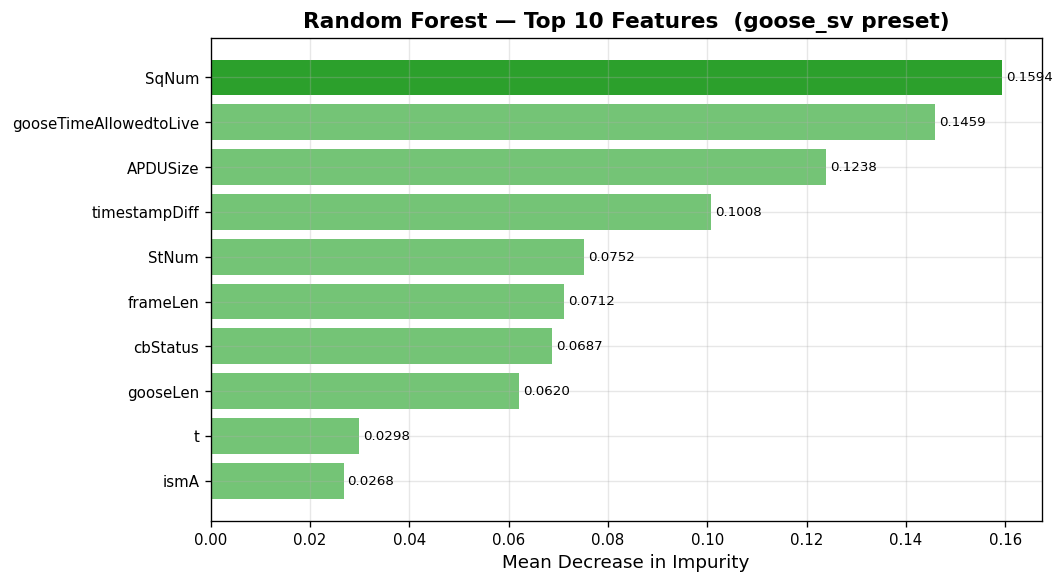

In [57]:
# ── Fixed winner params from capstone_notebook.ipynb ──────────────────────────
# Best RF: n_estimators=50, max_depth=None, min_samples_split=10, preset=all
RF_N_EST, RF_DEPTH, RF_SPLIT = 50, None, 10

rf_preset_metrics = {}
print("Random Forest — feature-set sweep")
print(f"  Fixed: n_estimators={RF_N_EST}  max_depth={RF_DEPTH}  "
      f"min_samples_split={RF_SPLIT}  class_weight=balanced\n")
print(f"  {'Preset':16s}  {'F1':>7}  {'AUC-ROC':>8}  {'Precision':>10}  {'Recall':>7}")
print("  " + "─" * 58)

for preset in SWEEP_PRESETS:
    X_tr, X_te, y_tr, y_te, fn = prepare_data(preset)
    rf = RandomForestClassifier(
        n_estimators=RF_N_EST, max_depth=RF_DEPTH, min_samples_split=RF_SPLIT,
        class_weight='balanced', random_state=SEED, n_jobs=-1,
    )
    rf.fit(X_tr, y_tr)
    y_pred  = rf.predict(X_te)
    y_proba = rf.predict_proba(X_te)[:, 1]
    m       = evaluate_classification(y_te, y_pred, y_proba)
    rf_preset_metrics[preset] = {**m,
        'y_pred': y_pred, 'y_score': y_proba,
        'y_te': y_te, 'model': rf, 'feat_names': fn, 'X_te': X_te}
    print(f"  {preset:16s}  {m['f1']:>7.4f}  {m['auc_roc']:>8.4f}"
          f"  {m['precision']:>10.4f}  {m['recall']:>7.4f}")

# ── Best preset ────────────────────────────────────────────────────────────────
best_rf_preset = max(rf_preset_metrics, key=lambda p: rf_preset_metrics[p]['f1'])
best_rf = {**rf_preset_metrics[best_rf_preset],
           'preset': best_rf_preset,
           'preset_metrics': {p: {k: v for k, v in r.items()
                                  if k in ('f1','precision','recall','accuracy','auc_roc')}
                              for p, r in rf_preset_metrics.items()}}
lat = measure_latency_sklearn(best_rf['model'], best_rf['X_te'][0])
best_rf['latency_ms'] = lat
results['Random Forest'] = best_rf

print(f"\n★  Best preset: {best_rf_preset}  |  F1={best_rf['f1']:.4f}"
      f"  AUC={best_rf['auc_roc']:.4f}  Latency={lat:.3f} ms\n")
print(classification_report(best_rf['y_te'], best_rf['y_pred'],
                             target_names=['Normal', 'Attack']))

# ── Chart 1: F1 & AUC-ROC by feature set ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
plot_preset_sweep(ax, best_rf['preset_metrics'], best_rf_preset,
                  'Random Forest — F1 & AUC-ROC by Feature Set')
plt.tight_layout(); plt.show()

# ── Chart 2: ROC + Confusion Matrix (best preset) ─────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Random Forest — Best Feature Set: {best_rf_preset}', fontweight='bold')
fpr, tpr, _ = roc_curve(best_rf['y_te'], best_rf['y_score'])
plot_roc(ax1, fpr, tpr, best_rf['auc_roc'], label='Random Forest', color='#2ca02c')
plot_cm(ax2, confusion_matrix(best_rf['y_te'], best_rf['y_pred']), cmap='Greens')
plt.tight_layout(); plt.show()

# ── Chart 3: Top-10 feature importances (best preset) ─────────────────────────
fi = pd.Series(best_rf['model'].feature_importances_,
               index=best_rf['feat_names']).nlargest(10).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fi.index, fi.values,
        color=['#2ca02c' if v == fi.max() else '#74c476' for v in fi])
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_title(f'Random Forest — Top 10 Features  ({best_rf_preset} preset)',
             fontweight='bold')
for i, v in enumerate(fi.values):
    ax.text(v + fi.max() * 0.005, i, f'{v:.4f}', va='center', fontsize=8)
plt.tight_layout(); plt.show()

## 4. MLP Autoencoder

**Winner from capstone exploration:** `bottleneck=8`, `lr=0.001`, `epochs=40`, best preset = `literature`

Trained only on normal samples; anomalies are detected by high reconstruction error.  
Swept across all 6 feature presets with these fixed hyperparameters.

MLP Autoencoder — feature-set sweep
  Fixed: bottleneck=8  lr=0.001  epochs=40

  Preset                 F1   AUC-ROC   Precision   Recall
  ──────────────────────────────────────────────────────────


AE goose_derived:   0%|          | 0/40 [00:00<?, ?it/s]

  goose_derived      0.2969    0.6080      0.2818   0.3137


AE literature:   0%|          | 0/40 [00:00<?, ?it/s]

  literature         0.5826    0.9050      0.4452   0.8427


AE goose_sv:   0%|          | 0/40 [00:00<?, ?it/s]

  goose_sv           0.4905    0.9440      0.3422   0.8657

★  Best preset: literature  |  F1=0.5826  AUC=0.9050  Latency=0.039 ms

              precision    recall  f1-score   support

      Normal       0.99      0.92      0.95   2755139
      Attack       0.45      0.84      0.58    200509

    accuracy                           0.92   2955648
   macro avg       0.72      0.88      0.77   2955648
weighted avg       0.95      0.92      0.93   2955648



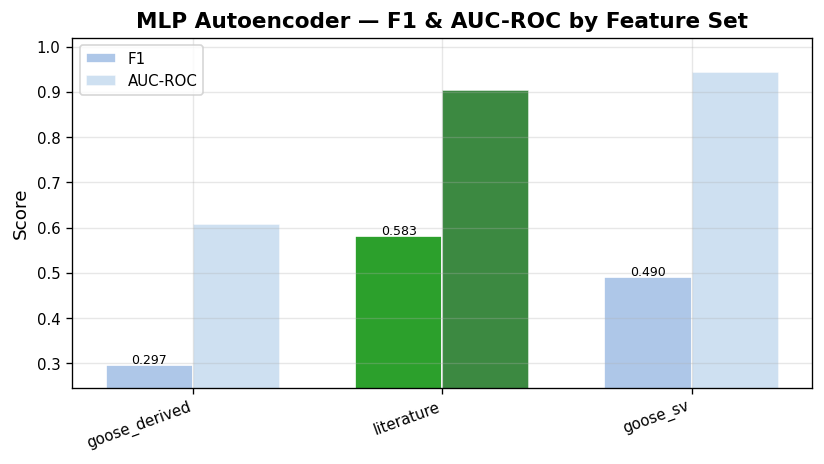

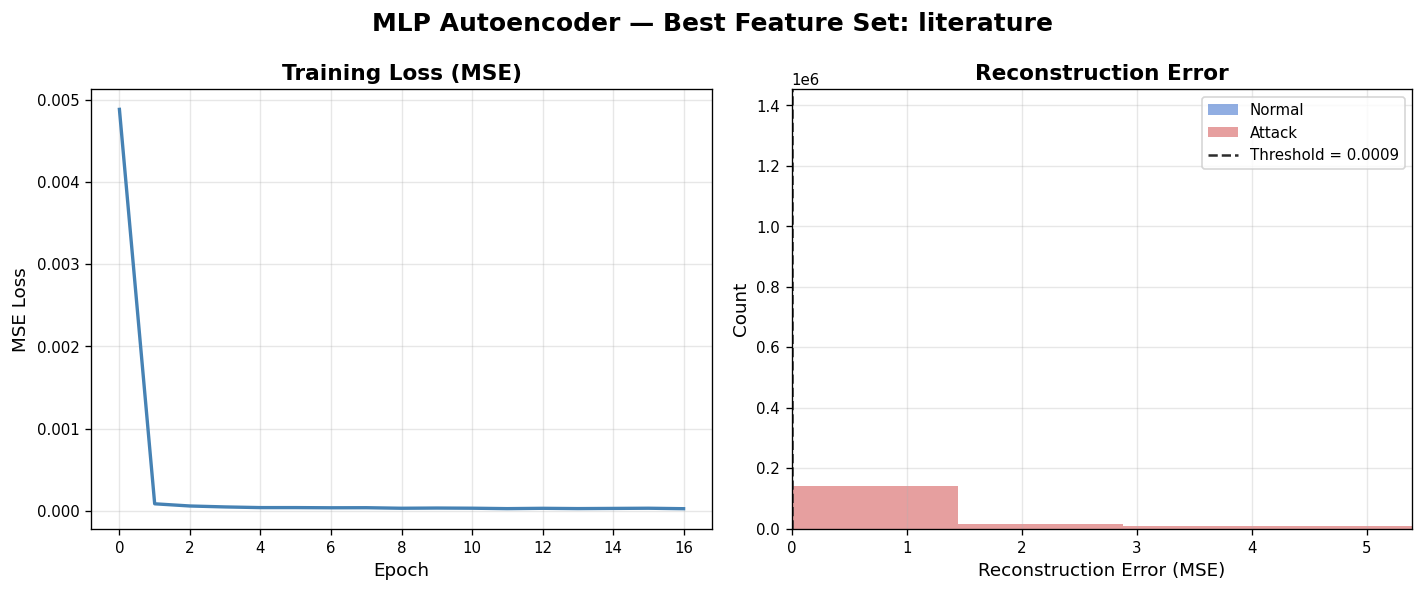

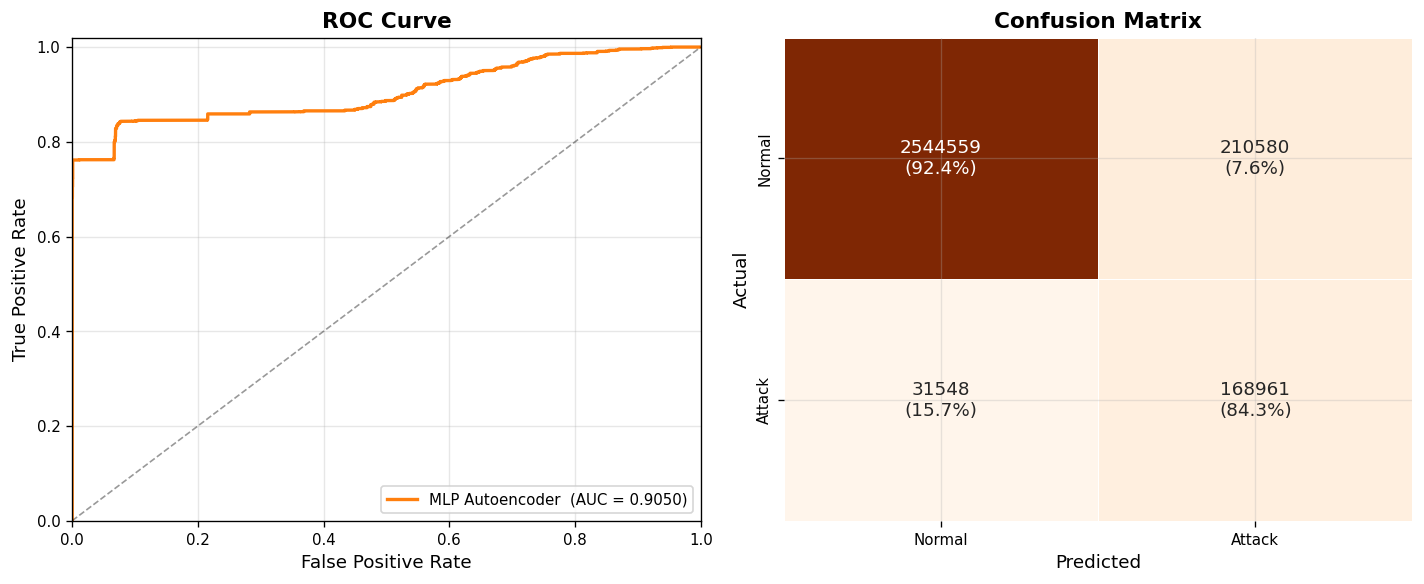

In [58]:
# ── Fixed winner params from capstone_notebook.ipynb ──────────────────────────
# Best AE: bottleneck=8, lr=0.001, epochs=40, preset=literature
AE_BNECK, AE_LR, AE_EPOCHS = 8, 1e-3, 40

ae_preset_metrics           = {}
best_ae_f1, best_ae_preset  = -1, None
best_ae_model = best_ae_losses = best_ae_errors = best_ae_thr = None
best_ae_y_pred = best_ae_y_te = best_ae_X_te_t = None

print("MLP Autoencoder — feature-set sweep")
print(f"  Fixed: bottleneck={AE_BNECK}  lr={AE_LR}  epochs={AE_EPOCHS}\n")
print(f"  {'Preset':16s}  {'F1':>7}  {'AUC-ROC':>8}  {'Precision':>10}  {'Recall':>7}")
print("  " + "─" * 58)

for preset in SWEEP_PRESETS:
    X_tr, X_te, y_tr, y_te, _ = prepare_data(preset)
    in_dim   = X_tr.shape[1]
    X_tr_nrm = torch.tensor(X_tr[y_tr == 0], dtype=torch.float32)
    X_te_t   = torch.tensor(X_te, dtype=torch.float32)
    train_dl = DataLoader(TensorDataset(X_tr_nrm, X_tr_nrm),
                          batch_size=256, shuffle=True, num_workers=0)
    mdl      = build_mlp_ae(in_dim, AE_BNECK).to(device)
    losses   = train_ae_flat(mdl, train_dl, AE_EPOCHS, AE_LR, device,
                             desc=f'AE {preset}')
    m, y_pred, errors, thr = evaluate_ae_flat(mdl, X_te_t, y_te, device)
    ae_preset_metrics[preset] = {k: m[k]
                                 for k in ('f1','precision','recall','accuracy','auc_roc')}
    print(f"  {preset:16s}  {m['f1']:>7.4f}  {m['auc_roc']:>8.4f}"
          f"  {m['precision']:>10.4f}  {m['recall']:>7.4f}")

    if m['f1'] > best_ae_f1:
        best_ae_f1, best_ae_preset = m['f1'], preset
        best_ae_model  = mdl
        best_ae_losses = losses
        best_ae_errors = errors
        best_ae_thr    = thr
        best_ae_y_pred = y_pred
        best_ae_y_te   = y_te
        best_ae_X_te_t = X_te_t
    else:
        del mdl
        if device.type == 'cuda': torch.cuda.empty_cache()

# ── Store best result ──────────────────────────────────────────────────────────
lat = measure_latency_torch(best_ae_model, best_ae_X_te_t[:1], device)
best_ae = {
    **ae_preset_metrics[best_ae_preset],
    'preset': best_ae_preset, 'preset_metrics': ae_preset_metrics,
    'model': best_ae_model, 'y_pred': best_ae_y_pred,
    'errors': best_ae_errors, 'threshold': best_ae_thr,
    'losses': best_ae_losses, 'y_te': best_ae_y_te,
    'latency_ms': lat,
}
results['MLP Autoencoder'] = best_ae

print(f"\n★  Best preset: {best_ae_preset}  |  F1={best_ae['f1']:.4f}"
      f"  AUC={best_ae['auc_roc']:.4f}  Latency={lat:.3f} ms\n")
print(classification_report(best_ae['y_te'], best_ae['y_pred'],
                             target_names=['Normal', 'Attack']))

# ── Chart 1: F1 & AUC by feature set ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
plot_preset_sweep(ax, ae_preset_metrics, best_ae_preset,
                  'MLP Autoencoder — F1 & AUC-ROC by Feature Set')
plt.tight_layout(); plt.show()

# ── Chart 2: Training loss + Reconstruction error (best preset) ───────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'MLP Autoencoder — Best Feature Set: {best_ae_preset}', fontweight='bold')
plot_loss(ax1, best_ae['losses'])
plot_error_dist(ax2, best_ae['errors'], best_ae['y_te'], best_ae['threshold'])
plt.tight_layout(); plt.show()

# ── Chart 3: ROC + Confusion Matrix (best preset) ─────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fpr, tpr, _ = roc_curve(best_ae['y_te'], best_ae['errors'])
plot_roc(ax1, fpr, tpr, best_ae['auc_roc'], label='MLP Autoencoder', color='#ff7f0e')
plot_cm(ax2, confusion_matrix(best_ae['y_te'], best_ae['y_pred']), cmap='Oranges')
plt.tight_layout(); plt.show()

## 5. LSTM Autoencoder

**Winner from capstone exploration:** `hidden=64`, `layers=2`, `dropout=0.2`, `lr=0.001`, `seq_len=10`, best preset = `literature`

Encoder–decoder LSTM trained on normal sliding-window sequences. Swept across all 6 feature presets.

LSTM Autoencoder — feature-set sweep
  Fixed: hidden=128  layers=2  dropout=0.2  lr=0.001  seq_len=10

  Preset                 F1   AUC-ROC   Precision   Recall
  ──────────────────────────────────────────────────────────


LSTM goose_derived:   0%|          | 0/40 [00:00<?, ?it/s]

  goose_derived      0.7377    0.7959      0.8969   0.6265


LSTM literature:   0%|          | 0/40 [00:00<?, ?it/s]

  literature         0.8670    0.9132      0.9932   0.7693


LSTM goose_sv:   0%|          | 0/40 [00:00<?, ?it/s]

  goose_sv           0.8686    0.9773      0.8704   0.8668

★  Best preset: goose_sv  |  F1=0.8686  AUC=0.9773  Latency=1.919 ms

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99    466189
      Attack       0.87      0.87      0.87     33811

    accuracy                           0.98    500000
   macro avg       0.93      0.93      0.93    500000
weighted avg       0.98      0.98      0.98    500000



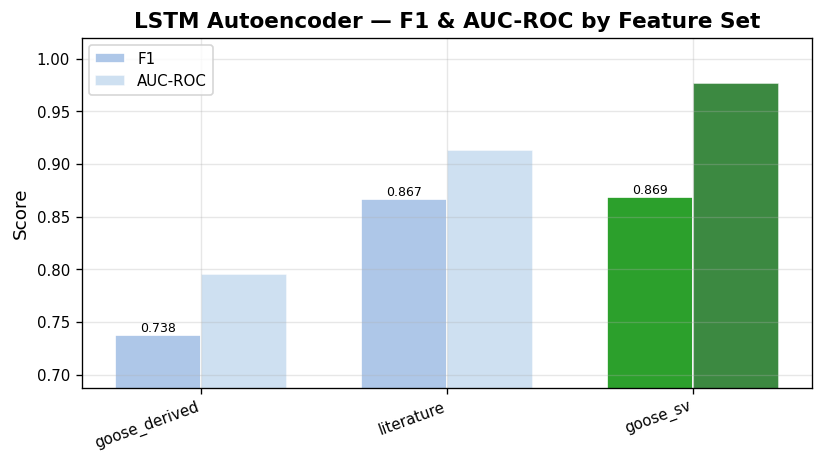

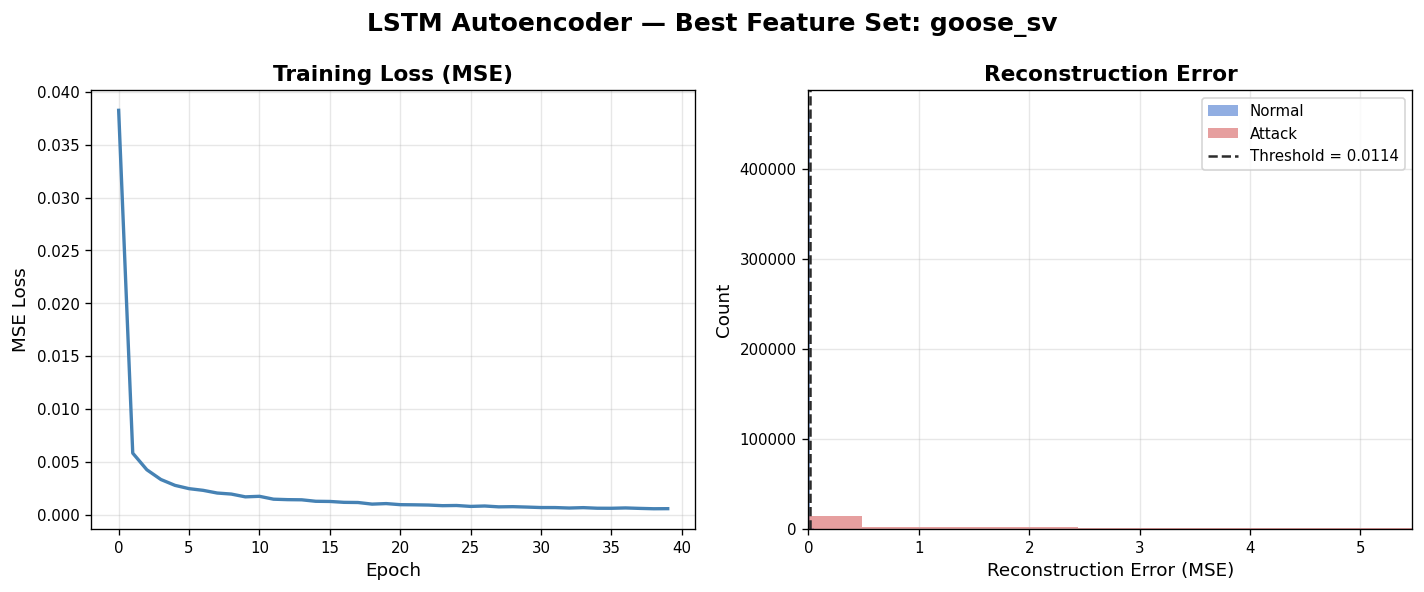

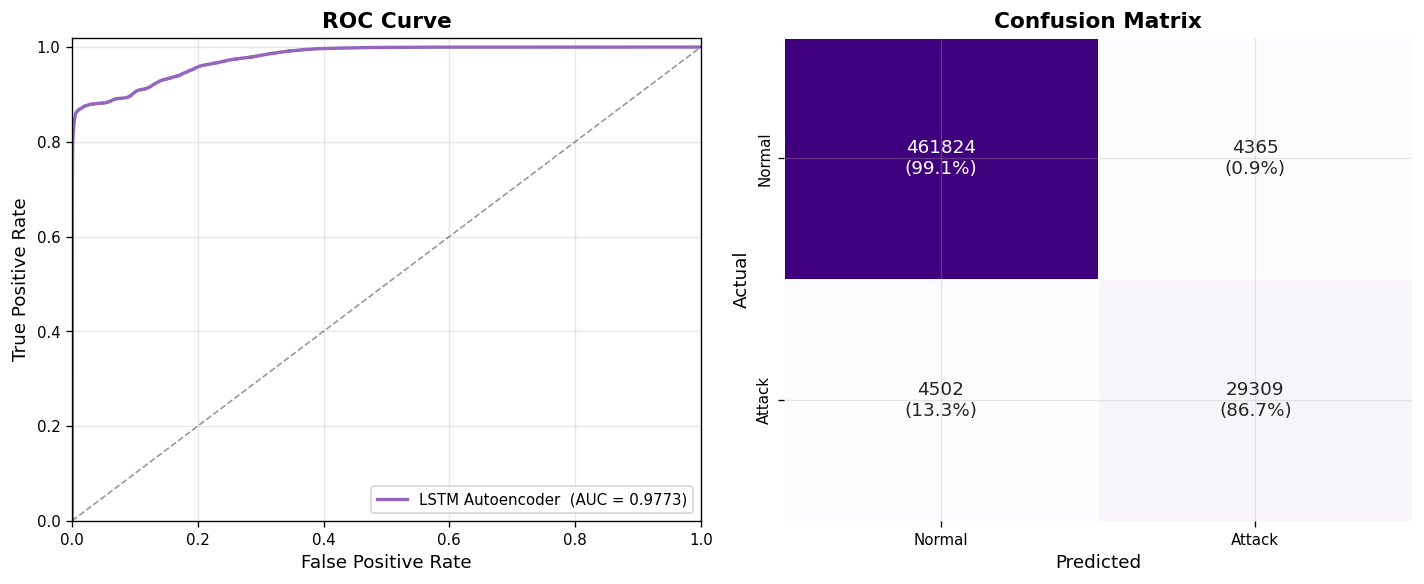

In [59]:
# ── Fixed winner params from capstone_notebook.ipynb ──────────────────────────
# Best LSTM: hidden=128, layers=2, dropout=0.2, lr=0.001, seq_len=10, preset=literature
LSTM_HID, LSTM_NL, LSTM_DROP, LSTM_LR, LSTM_SEQ = 128, 2, 0.2, 1e-3, 10

lstm_preset_metrics                 = {}
best_lstm_f1, best_lstm_preset      = -1, None
best_lstm_model = best_lstm_losses  = best_lstm_errors = None
best_lstm_thr = best_lstm_y_pred = best_lstm_y_labels = None

print("LSTM Autoencoder — feature-set sweep")
print(f"  Fixed: hidden={LSTM_HID}  layers={LSTM_NL}  dropout={LSTM_DROP}"
      f"  lr={LSTM_LR}  seq_len={LSTM_SEQ}\n")
print(f"  {'Preset':16s}  {'F1':>7}  {'AUC-ROC':>8}  {'Precision':>10}  {'Recall':>7}")
print("  " + "─" * 58)

for preset in SWEEP_PRESETS:
    X_tr, X_te, y_tr, y_te, _ = prepare_data(preset)
    cache_key = (preset, LSTM_SEQ)
    if cache_key not in _loader_cache:
        _loader_cache[cache_key] = build_sequence_loaders(
            X_tr, y_tr, X_te, y_te, seq_len=LSTM_SEQ, batch_size=256)
    train_dl, test_dl, y_labels = _loader_cache[cache_key]

    mdl    = LSTMAutoencoder(X_tr.shape[1], LSTM_HID, LSTM_NL, LSTM_DROP).to(device)
    losses = train_seq_model(mdl, train_dl, 40, LSTM_LR, device,
                             desc=f'LSTM {preset}')
    m, y_pred, errors, thr = evaluate_seq_model(mdl, test_dl, y_labels, device)
    lstm_preset_metrics[preset] = {k: m[k]
                                   for k in ('f1','precision','recall','accuracy','auc_roc')}
    print(f"  {preset:16s}  {m['f1']:>7.4f}  {m['auc_roc']:>8.4f}"
          f"  {m['precision']:>10.4f}  {m['recall']:>7.4f}")

    if m['f1'] > best_lstm_f1:
        best_lstm_f1, best_lstm_preset = m['f1'], preset
        best_lstm_model   = mdl
        best_lstm_losses  = losses
        best_lstm_errors  = errors
        best_lstm_thr     = thr
        best_lstm_y_pred  = y_pred
        best_lstm_y_labels = y_labels
        best_lstm_m       = m
    else:
        del mdl
        if device.type == 'cuda': torch.cuda.empty_cache()

# ── Store best result ──────────────────────────────────────────────────────────
sample = next(iter(_loader_cache[(best_lstm_preset, LSTM_SEQ)][1]))[0][:1]
lat    = measure_latency_torch(best_lstm_model, sample, device)
best_lstm = {
    **best_lstm_m,
    'preset': best_lstm_preset, 'preset_metrics': lstm_preset_metrics,
    'model': best_lstm_model, 'y_pred': best_lstm_y_pred,
    'errors': best_lstm_errors, 'threshold': best_lstm_thr,
    'losses': best_lstm_losses, 'y_labels': best_lstm_y_labels,
    'latency_ms': lat,
}
results['LSTM'] = best_lstm

print(f"\n★  Best preset: {best_lstm_preset}  |  F1={best_lstm['f1']:.4f}"
      f"  AUC={best_lstm['auc_roc']:.4f}  Latency={lat:.3f} ms\n")
print(classification_report(best_lstm_y_labels, best_lstm_y_pred,
                             target_names=['Normal', 'Attack']))

# ── Chart 1: F1 & AUC by feature set ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
plot_preset_sweep(ax, lstm_preset_metrics, best_lstm_preset,
                  'LSTM Autoencoder — F1 & AUC-ROC by Feature Set')
plt.tight_layout(); plt.show()

# ── Chart 2: Training loss + Reconstruction error (best preset) ───────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'LSTM Autoencoder — Best Feature Set: {best_lstm_preset}', fontweight='bold')
plot_loss(ax1, best_lstm['losses'])
plot_error_dist(ax2, best_lstm['errors'], best_lstm['y_labels'], best_lstm['threshold'])
plt.tight_layout(); plt.show()

# ── Chart 3: ROC + Confusion Matrix (best preset) ─────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fpr, tpr, _ = roc_curve(best_lstm['y_labels'], best_lstm['errors'])
plot_roc(ax1, fpr, tpr, best_lstm['auc_roc'], label='LSTM Autoencoder', color='#9467bd')
plot_cm(ax2, confusion_matrix(best_lstm['y_labels'], best_lstm['y_pred']), cmap='Purples')
plt.tight_layout(); plt.show()

## 4. RNN Autoencoder

Vanilla Recurrent Neural Network encoder-decoder trained to reconstruct normal-traffic sequences. Anomalies produce higher reconstruction error.

**Winner configuration** (from capstone_notebook.ipynb grid search):

| Hyper-parameter | Value |
|---|---|
| Hidden units | 128 |
| Layers | 2 |
| Dropout | 0.2 |
| Learning rate | 0.001 |
| Sequence length | 10 |
| Best feature preset | `goose_full` |

These fixed params are swept across all 6 feature sets to show the impact of input representation on model performance.

RNN Autoencoder — feature-set sweep
  Fixed: hidden=128  layers=2  dropout=0.2  lr=0.001  seq_len=10

  Preset                 F1   AUC-ROC   Precision   Recall
  ──────────────────────────────────────────────────────────


RNN goose_derived:   0%|          | 0/40 [00:00<?, ?it/s]

  goose_derived      0.4613    0.8134      0.3494   0.6788


RNN literature:   0%|          | 0/40 [00:00<?, ?it/s]

  literature         0.8637    0.9110      0.9359   0.8018


RNN goose_sv:   0%|          | 0/40 [00:00<?, ?it/s]

  goose_sv           0.7576    0.9393      0.7021   0.8225

★  Best preset: literature  |  F1=0.8637  AUC=0.9110  Latency=1.228 ms

              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99    466189
      Attack       0.94      0.80      0.86     33811

    accuracy                           0.98    500000
   macro avg       0.96      0.90      0.93    500000
weighted avg       0.98      0.98      0.98    500000



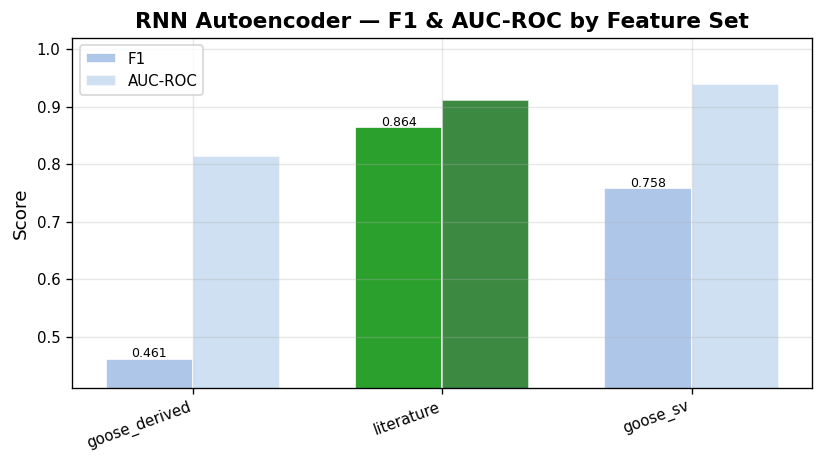

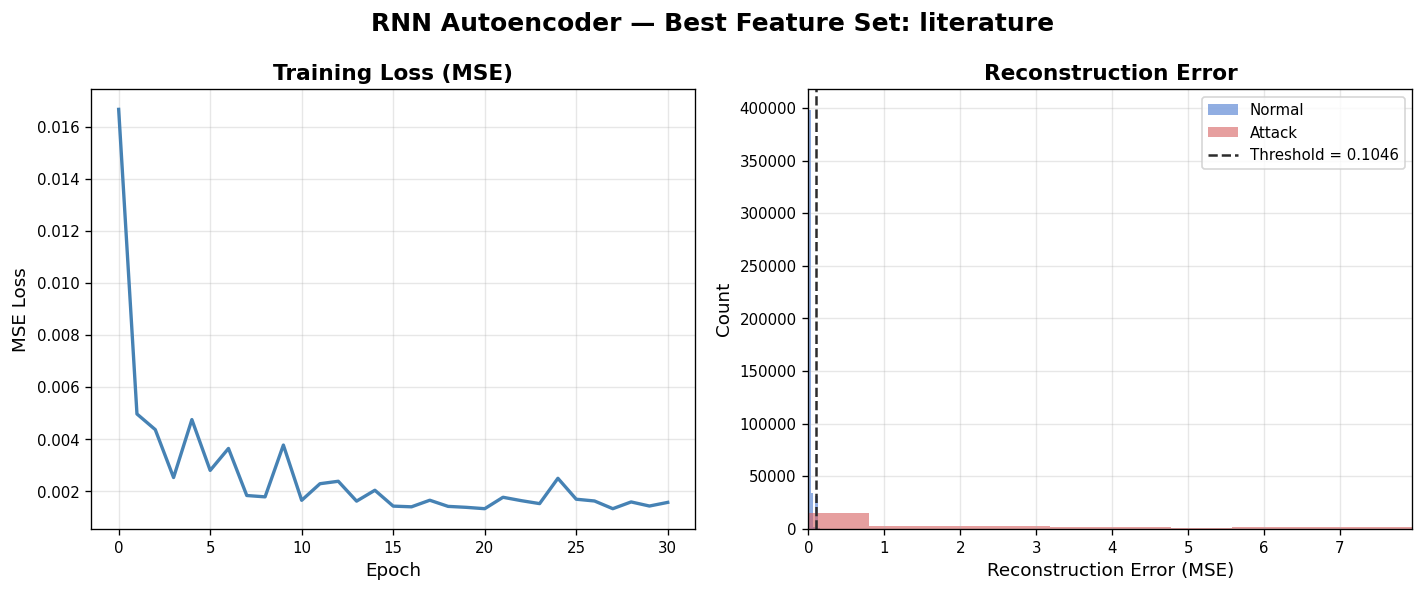

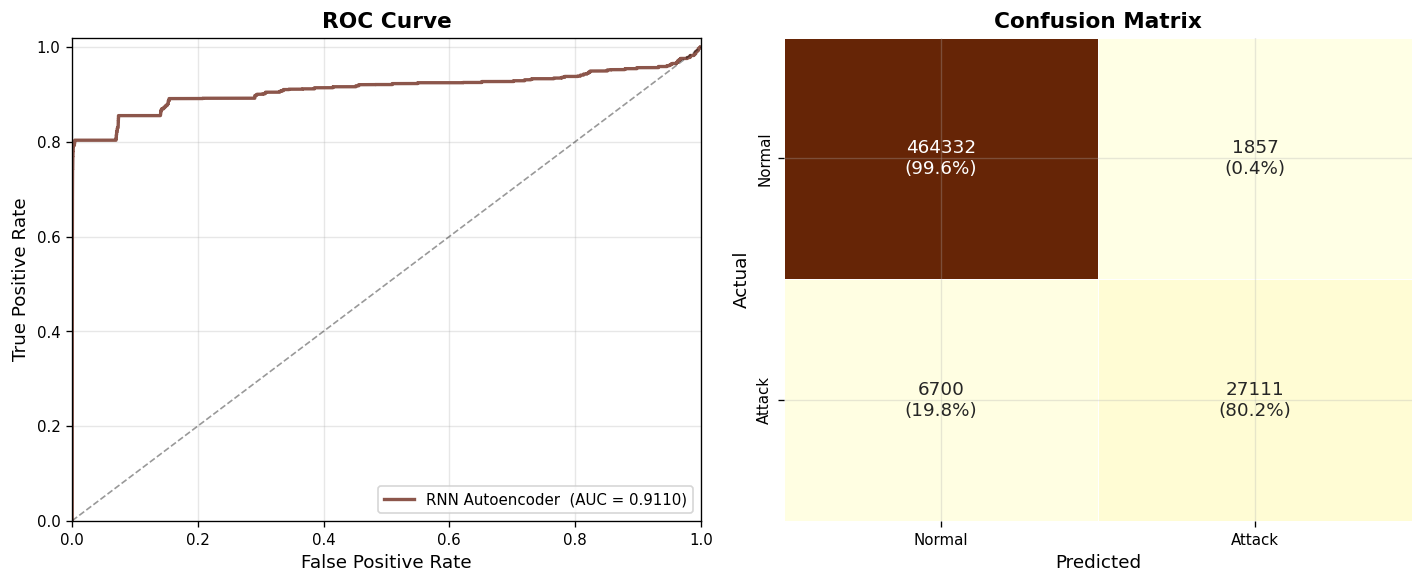

In [60]:
# ── Fixed winner params from capstone_notebook.ipynb ──────────────────────────
# Best RNN: hidden=128, layers=2, dropout=0.2, lr=0.001, seq_len=10, preset=goose_full
RNN_HID, RNN_NL, RNN_DROP, RNN_LR, RNN_SEQ = 128, 2, 0.2, 1e-3, 10

rnn_preset_metrics                = {}
best_rnn_f1, best_rnn_preset      = -1, None
best_rnn_model = best_rnn_losses  = best_rnn_errors = None
best_rnn_thr = best_rnn_y_pred = best_rnn_y_labels = None

print("RNN Autoencoder — feature-set sweep")
print(f"  Fixed: hidden={RNN_HID}  layers={RNN_NL}  dropout={RNN_DROP}"
      f"  lr={RNN_LR}  seq_len={RNN_SEQ}\n")
print(f"  {'Preset':16s}  {'F1':>7}  {'AUC-ROC':>8}  {'Precision':>10}  {'Recall':>7}")
print("  " + "─" * 58)

for preset in SWEEP_PRESETS:
    X_tr, X_te, y_tr, y_te, _ = prepare_data(preset)
    cache_key = (preset, RNN_SEQ)
    if cache_key not in _loader_cache:
        _loader_cache[cache_key] = build_sequence_loaders(
            X_tr, y_tr, X_te, y_te, seq_len=RNN_SEQ, batch_size=256)
    train_dl, test_dl, y_labels = _loader_cache[cache_key]

    mdl    = RNNAutoencoder(X_tr.shape[1], RNN_HID, RNN_NL, RNN_DROP).to(device)
    losses = train_seq_model(mdl, train_dl, 40, RNN_LR, device,
                             desc=f'RNN {preset}')
    m, y_pred, errors, thr = evaluate_seq_model(mdl, test_dl, y_labels, device)
    rnn_preset_metrics[preset] = {k: m[k]
                                  for k in ('f1','precision','recall','accuracy','auc_roc')}
    print(f"  {preset:16s}  {m['f1']:>7.4f}  {m['auc_roc']:>8.4f}"
          f"  {m['precision']:>10.4f}  {m['recall']:>7.4f}")

    if m['f1'] > best_rnn_f1:
        best_rnn_f1, best_rnn_preset = m['f1'], preset
        best_rnn_model   = mdl
        best_rnn_losses  = losses
        best_rnn_errors  = errors
        best_rnn_thr     = thr
        best_rnn_y_pred  = y_pred
        best_rnn_y_labels = y_labels
        best_rnn_m       = m
    else:
        del mdl
        if device.type == 'cuda': torch.cuda.empty_cache()

# ── Store best result ──────────────────────────────────────────────────────────
sample = next(iter(_loader_cache[(best_rnn_preset, RNN_SEQ)][1]))[0][:1]
lat    = measure_latency_torch(best_rnn_model, sample, device)
best_rnn = {
    **best_rnn_m,
    'preset': best_rnn_preset, 'preset_metrics': rnn_preset_metrics,
    'model': best_rnn_model, 'y_pred': best_rnn_y_pred,
    'errors': best_rnn_errors, 'threshold': best_rnn_thr,
    'losses': best_rnn_losses, 'y_labels': best_rnn_y_labels,
    'latency_ms': lat,
}
results['RNN'] = best_rnn

print(f"\n★  Best preset: {best_rnn_preset}  |  F1={best_rnn['f1']:.4f}"
      f"  AUC={best_rnn['auc_roc']:.4f}  Latency={lat:.3f} ms\n")
print(classification_report(best_rnn_y_labels, best_rnn_y_pred,
                             target_names=['Normal', 'Attack']))

# ── Chart 1: F1 & AUC by feature set ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
plot_preset_sweep(ax, rnn_preset_metrics, best_rnn_preset,
                  'RNN Autoencoder — F1 & AUC-ROC by Feature Set')
plt.tight_layout(); plt.show()

# ── Chart 2: Training loss + Reconstruction error (best preset) ───────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'RNN Autoencoder — Best Feature Set: {best_rnn_preset}', fontweight='bold')
plot_loss(ax1, best_rnn['losses'])
plot_error_dist(ax2, best_rnn['errors'], best_rnn['y_labels'], best_rnn['threshold'])
plt.tight_layout(); plt.show()

# ── Chart 3: ROC + Confusion Matrix (best preset) ─────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fpr, tpr, _ = roc_curve(best_rnn['y_labels'], best_rnn['errors'])
plot_roc(ax1, fpr, tpr, best_rnn['auc_roc'], label='RNN Autoencoder', color='#8c564b')
plot_cm(ax2, confusion_matrix(best_rnn['y_labels'], best_rnn['y_pred']), cmap='YlOrBr')
plt.tight_layout(); plt.show()

## 5. GRU Autoencoder

Gated Recurrent Unit encoder-decoder. GRU gating reduces vanishing-gradient issues compared to vanilla RNN while using fewer parameters than LSTM.

**Winner configuration** (from capstone_notebook.ipynb grid search):

| Hyper-parameter | Value |
|---|---|
| Hidden units | 128 |
| Layers | 2 |
| Dropout | 0.2 |
| Learning rate | 0.002 |
| Sequence length | 5 |
| Best feature preset | `literature` |

These fixed params are swept across all 6 feature sets. Note the shorter sequence length (5 vs 10 for LSTM/RNN) and slightly higher learning rate.


GRU Autoencoder — feature-set sweep
  Fixed: hidden=128  layers=2  dropout=0.2  lr=0.002  seq_len=5

  Preset                 F1   AUC-ROC   Precision   Recall
  ──────────────────────────────────────────────────────────


GRU goose_derived:   0%|          | 0/40 [00:00<?, ?it/s]

  goose_derived      0.5663    0.8474      0.4840   0.6822


GRU literature:   0%|          | 0/40 [00:00<?, ?it/s]

  literature         0.8737    0.9443      0.8938   0.8545


GRU goose_sv:   0%|          | 0/40 [00:00<?, ?it/s]

  goose_sv           0.7529    0.9749      0.6619   0.8729

★  Best preset: literature  |  F1=0.8737  AUC=0.9443  Latency=1.117 ms

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99    466202
      Attack       0.89      0.85      0.87     33798

    accuracy                           0.98    500000
   macro avg       0.94      0.92      0.93    500000
weighted avg       0.98      0.98      0.98    500000



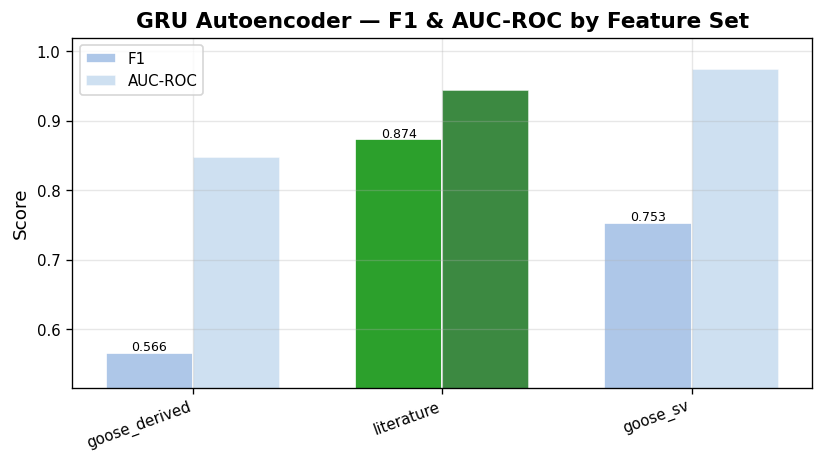

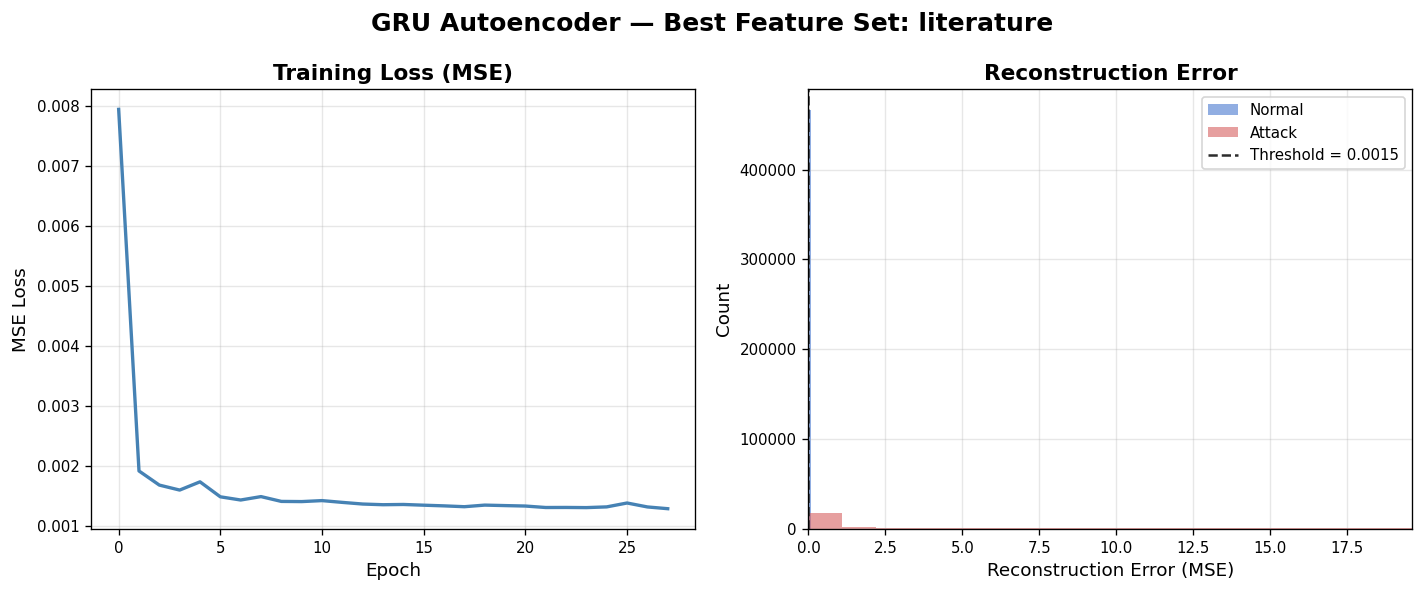

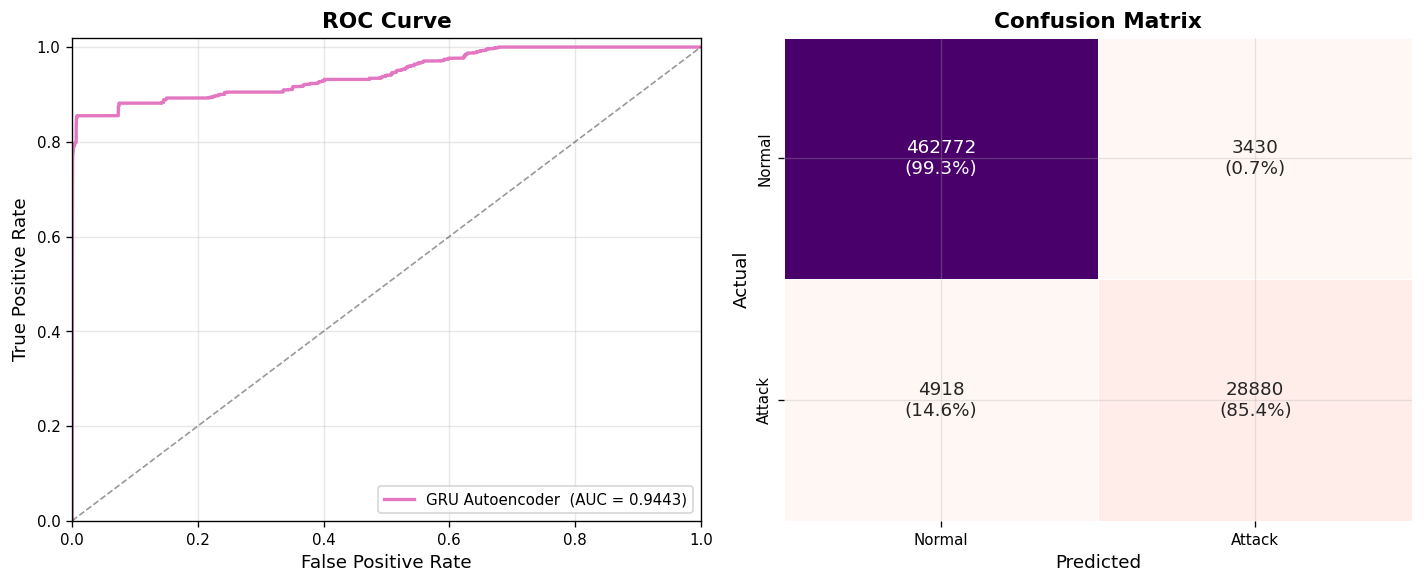

In [61]:
# ── Fixed winner params from capstone_notebook.ipynb ──────────────────────────
# Best GRU: hidden=128, layers=2, dropout=0.2, lr=0.002, seq_len=5, preset=literature
GRU_HID, GRU_NL, GRU_DROP, GRU_LR, GRU_SEQ = 128, 2, 0.2, 2e-3, 5

gru_preset_metrics                = {}
best_gru_f1, best_gru_preset      = -1, None
best_gru_model = best_gru_losses  = best_gru_errors = None
best_gru_thr = best_gru_y_pred = best_gru_y_labels = None

print("GRU Autoencoder — feature-set sweep")
print(f"  Fixed: hidden={GRU_HID}  layers={GRU_NL}  dropout={GRU_DROP}"
      f"  lr={GRU_LR}  seq_len={GRU_SEQ}\n")
print(f"  {'Preset':16s}  {'F1':>7}  {'AUC-ROC':>8}  {'Precision':>10}  {'Recall':>7}")
print("  " + "─" * 58)

for preset in SWEEP_PRESETS:
    X_tr, X_te, y_tr, y_te, _ = prepare_data(preset)
    cache_key = (preset, GRU_SEQ)
    if cache_key not in _loader_cache:
        _loader_cache[cache_key] = build_sequence_loaders(
            X_tr, y_tr, X_te, y_te, seq_len=GRU_SEQ, batch_size=256)
    train_dl, test_dl, y_labels = _loader_cache[cache_key]

    mdl    = GRUAutoencoder(X_tr.shape[1], GRU_HID, GRU_NL, GRU_DROP).to(device)
    losses = train_seq_model(mdl, train_dl, 40, GRU_LR, device,
                             desc=f'GRU {preset}')
    m, y_pred, errors, thr = evaluate_seq_model(mdl, test_dl, y_labels, device)
    gru_preset_metrics[preset] = {k: m[k]
                                  for k in ('f1','precision','recall','accuracy','auc_roc')}
    print(f"  {preset:16s}  {m['f1']:>7.4f}  {m['auc_roc']:>8.4f}"
          f"  {m['precision']:>10.4f}  {m['recall']:>7.4f}")

    if m['f1'] > best_gru_f1:
        best_gru_f1, best_gru_preset = m['f1'], preset
        best_gru_model   = mdl
        best_gru_losses  = losses
        best_gru_errors  = errors
        best_gru_thr     = thr
        best_gru_y_pred  = y_pred
        best_gru_y_labels = y_labels
        best_gru_m       = m
    else:
        del mdl
        if device.type == 'cuda': torch.cuda.empty_cache()

# ── Store best result ──────────────────────────────────────────────────────────
sample = next(iter(_loader_cache[(best_gru_preset, GRU_SEQ)][1]))[0][:1]
lat    = measure_latency_torch(best_gru_model, sample, device)
best_gru = {
    **best_gru_m,
    'preset': best_gru_preset, 'preset_metrics': gru_preset_metrics,
    'model': best_gru_model, 'y_pred': best_gru_y_pred,
    'errors': best_gru_errors, 'threshold': best_gru_thr,
    'losses': best_gru_losses, 'y_labels': best_gru_y_labels,
    'latency_ms': lat,
}
results['GRU'] = best_gru

print(f"\n★  Best preset: {best_gru_preset}  |  F1={best_gru['f1']:.4f}"
      f"  AUC={best_gru['auc_roc']:.4f}  Latency={lat:.3f} ms\n")
print(classification_report(best_gru_y_labels, best_gru_y_pred,
                             target_names=['Normal', 'Attack']))

# ── Chart 1: F1 & AUC by feature set ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
plot_preset_sweep(ax, gru_preset_metrics, best_gru_preset,
                  'GRU Autoencoder — F1 & AUC-ROC by Feature Set')
plt.tight_layout(); plt.show()

# ── Chart 2: Training loss + Reconstruction error (best preset) ───────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'GRU Autoencoder — Best Feature Set: {best_gru_preset}', fontweight='bold')
plot_loss(ax1, best_gru['losses'])
plot_error_dist(ax2, best_gru['errors'], best_gru['y_labels'], best_gru['threshold'])
plt.tight_layout(); plt.show()

# ── Chart 3: ROC + Confusion Matrix (best preset) ─────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fpr, tpr, _ = roc_curve(best_gru['y_labels'], best_gru['errors'])
plot_roc(ax1, fpr, tpr, best_gru['auc_roc'], label='GRU Autoencoder', color='#e377c2')
plot_cm(ax2, confusion_matrix(best_gru['y_labels'], best_gru['y_pred']), cmap='RdPu')
plt.tight_layout(); plt.show()

## 6. Model Comparison & Feature-Set Analysis

Consolidated view across all five models using their respective winner configurations.

**Charts produced:**
1. **F1-Score & Latency** — bar chart comparing best-preset performance of each model against the 4 ms GOOSE latency deadline
2. **Precision / Recall / F1** — grouped bars per model at best preset
3. **ROC Overlay** — all models on a single AUC plot at best preset
4. **Feature-Set × Model Heatmap (F1)** — shows how each model responds to different feature representations (rows = presets, columns = models)
5. **Feature-Set × Model Heatmap (AUC-ROC)** — same layout for AUC-ROC


MODEL COMPARISON SUMMARY
                Best Preset     F1  Precision  Recall  Accuracy  AUC-ROC  Latency (ms)
Model                                                                                 
Random Forest      goose_sv 0.9516     0.9423  0.9612    0.9934   0.9937       21.8374
MLP Autoencoder  literature 0.5826     0.4452  0.8427    0.9181   0.9050        0.0388
LSTM               goose_sv 0.8686     0.8704  0.8668    0.9823   0.9773        1.9195
RNN              literature 0.8637     0.9359  0.8018    0.9829   0.9110        1.2285
GRU              literature 0.8737     0.8938  0.8545    0.9833   0.9443        1.1175



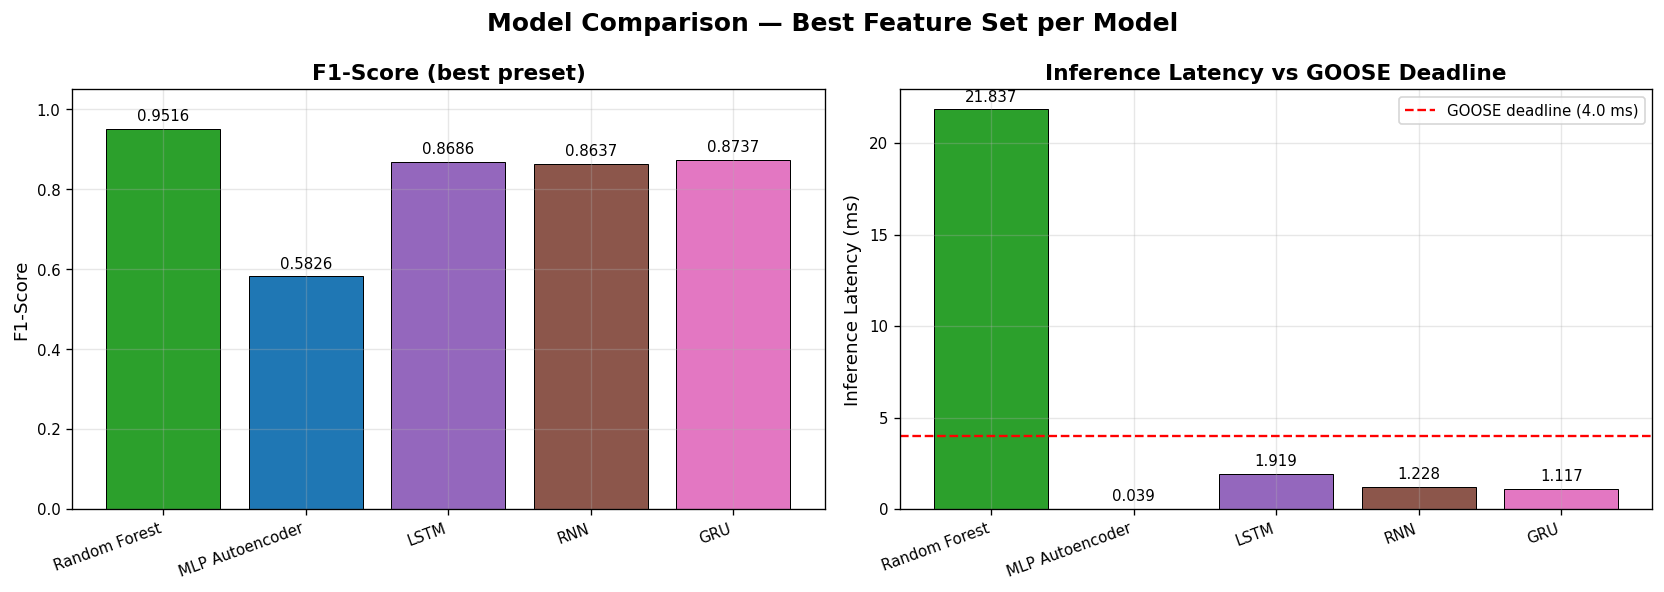

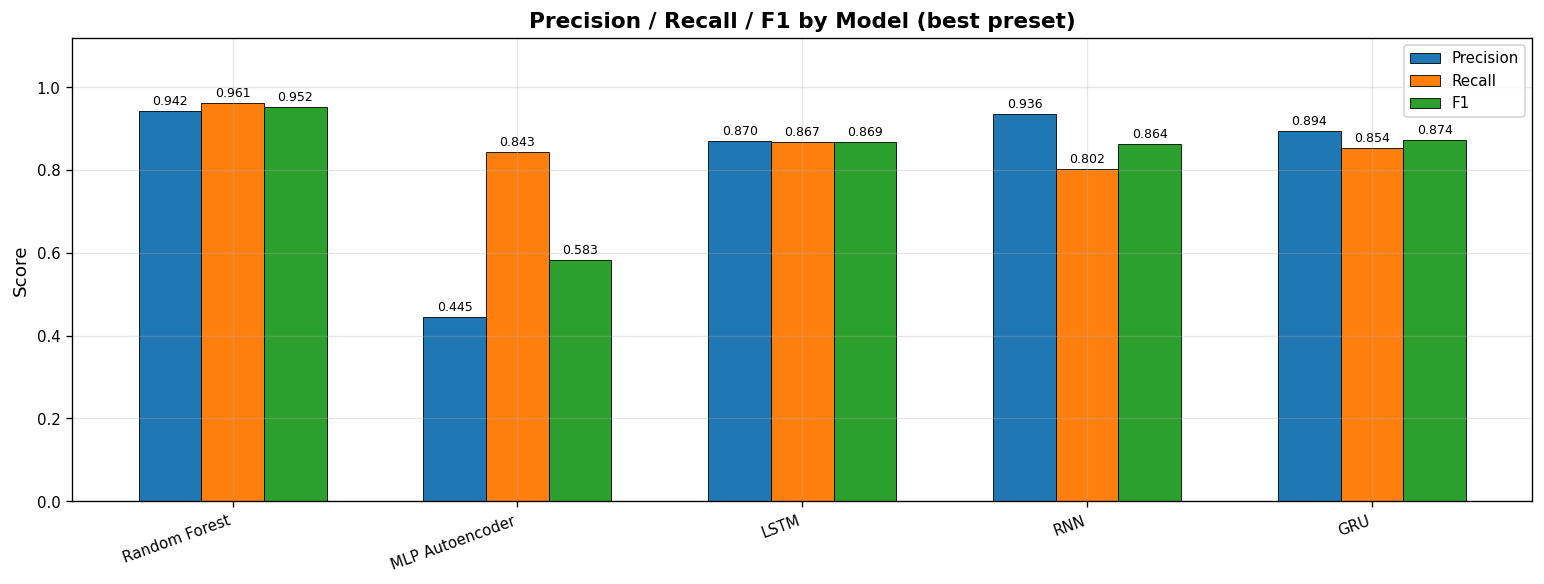

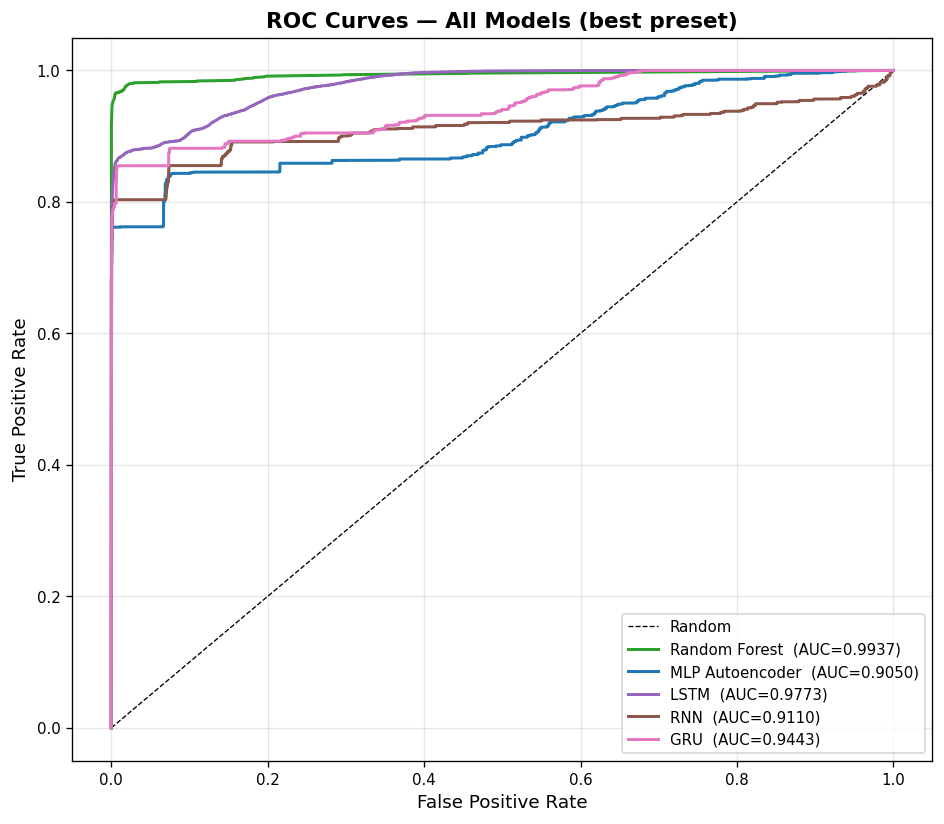

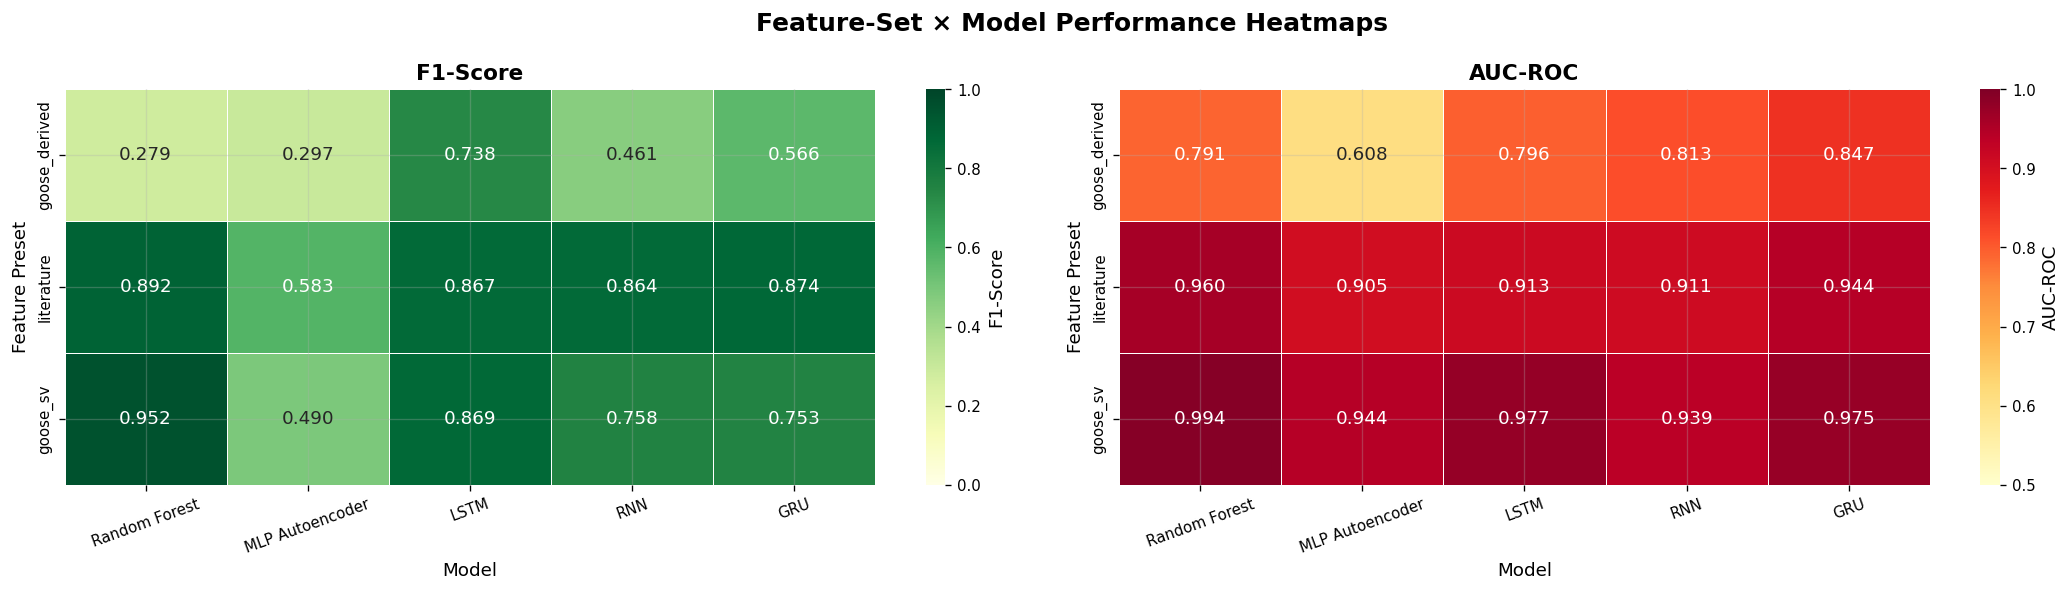


Best model per feature preset (by F1):
goose_derived             LSTM
literature       Random Forest
goose_sv         Random Forest


In [62]:
MODEL_ORDER  = ['Random Forest', 'MLP Autoencoder', 'LSTM', 'RNN', 'GRU']
PALETTE      = ['#2ca02c', '#1f77b4', '#9467bd', '#8c564b', '#e377c2']
GOOSE_LIMIT  = 4.0   # ms

# ── Aggregate summary table ────────────────────────────────────────────────────
summary = []
for name in MODEL_ORDER:
    r = results[name]
    summary.append({
        'Model':       name,
        'Best Preset': r['preset'],
        'F1':          r['f1'],
        'Precision':   r['precision'],
        'Recall':      r['recall'],
        'Accuracy':    r['accuracy'],
        'AUC-ROC':     r['auc_roc'],
        'Latency (ms)':r['latency_ms'],
    })
df_summary = pd.DataFrame(summary).set_index('Model')
print("=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)
print(df_summary.to_string(float_format=lambda x: f'{x:.4f}'))
print()

# ── Chart 1: F1 & Latency ─────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison — Best Feature Set per Model', fontweight='bold')

names  = df_summary.index.tolist()
f1s    = df_summary['F1'].values
lats   = df_summary['Latency (ms)'].values
x      = np.arange(len(names))

bars = ax1.bar(x, f1s, color=PALETTE, edgecolor='black', linewidth=0.6)
ax1.set_xticks(x); ax1.set_xticklabels(names, rotation=20, ha='right')
ax1.set_ylim(0, 1.05); ax1.set_ylabel('F1-Score')
ax1.set_title('F1-Score (best preset)')
ax1.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax1.grid(axis='y', alpha=0.3)

bars2 = ax2.bar(x, lats, color=PALETTE, edgecolor='black', linewidth=0.6)
ax2.axhline(GOOSE_LIMIT, color='red', linestyle='--', linewidth=1.4,
            label=f'GOOSE deadline ({GOOSE_LIMIT} ms)')
ax2.set_xticks(x); ax2.set_xticklabels(names, rotation=20, ha='right')
ax2.set_ylabel('Inference Latency (ms)')
ax2.set_title('Inference Latency vs GOOSE Deadline')
ax2.bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)
ax2.legend(); ax2.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# ── Chart 2: Precision / Recall / F1 grouped bars ─────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
metrics   = ['Precision', 'Recall', 'F1']
n_metrics = len(metrics)
width     = 0.22
offsets   = np.linspace(-(n_metrics - 1) * width / 2,
                         (n_metrics - 1) * width / 2, n_metrics)
for i, (met, off) in enumerate(zip(metrics, offsets)):
    vals = df_summary[met].values
    b = ax.bar(x + off, vals, width, label=met, edgecolor='black', linewidth=0.5)
    ax.bar_label(b, fmt='%.3f', padding=2, fontsize=7.5)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 by Model (best preset)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# ── Chart 3: ROC Overlay ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random')
for name, col in zip(MODEL_ORDER, PALETTE):
    r = results[name]
    # support both key conventions (RF uses 'y_te', seq models use 'y_labels')
    y_true = r.get('y_labels', r.get('y_te'))
    if y_true is None:
        continue
    # use reconstruction error when available, otherwise use probability score
    score = r['errors'] if 'errors' in r else r.get('y_score', r.get('y_pred'))
    if score is None:
        continue
    fpr, tpr, _ = roc_curve(y_true, score)
    ax.plot(fpr, tpr, color=col, lw=1.8,
            label=f"{name}  (AUC={r['auc_roc']:.4f})")
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models (best preset)')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ── Chart 4 & 5: Feature-Set × Model heatmaps ────────────────────────────────
f1_rows, auc_rows = {}, {}
for name in MODEL_ORDER:
    pm = results[name].get('preset_metrics', {})
    f1_rows[name]  = {p: pm[p]['f1']      for p in SWEEP_PRESETS if p in pm}
    auc_rows[name] = {p: pm[p]['auc_roc'] for p in SWEEP_PRESETS if p in pm}

f1_df  = pd.DataFrame(f1_rows).reindex(SWEEP_PRESETS)
auc_df = pd.DataFrame(auc_rows).reindex(SWEEP_PRESETS)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Feature-Set × Model Performance Heatmaps', fontweight='bold')

sns.heatmap(f1_df.astype(float), annot=True, fmt='.3f',
            cmap='YlGn', vmin=0, vmax=1,
            linewidths=0.5, linecolor='white',
            ax=ax1, cbar_kws={'label': 'F1-Score'})
ax1.set_title('F1-Score')
ax1.set_xlabel('Model'); ax1.set_ylabel('Feature Preset')
ax1.tick_params(axis='x', rotation=20)

sns.heatmap(auc_df.astype(float), annot=True, fmt='.3f',
            cmap='YlOrRd', vmin=0.5, vmax=1,
            linewidths=0.5, linecolor='white',
            ax=ax2, cbar_kws={'label': 'AUC-ROC'})
ax2.set_title('AUC-ROC')
ax2.set_xlabel('Model'); ax2.set_ylabel('Feature Preset')
ax2.tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.show()

# ── Best-preset per feature set ────────────────────────────────────────────────
print("\nBest model per feature preset (by F1):")
print(f1_df.idxmax(axis=1).to_string())

## 7. Cross-Environment Generalizability Analysis

Tests all five trained models — **without any retraining** — against a second IEC 61850 dataset captured in a different physical testbed (different IEDs, substation layout, and traffic patterns).

### Dataset
The archive dataset contains pre-processed GOOSE traffic for four attack types:

| Attack Type | Description |
|---|---|
| Masquerade | Attacker impersonates a legitimate IED |
| Message Injection | Spurious GOOSE frames inserted into the stream |
| Poisoning | Gradual corruption of GOOSE state counters |
| Replay | Captured legitimate frames re-transmitted |

Each test file contains a mix of normal background traffic (`target=0`) and labelled attack samples (`target=1`).

### Methodology
- Column names differ between datasets; a curated mapping aligns archive features to the ERENO convention.
- Features present in ERENO but absent from the archive (`cbStatus`, `APDUSize`) are filled with the **ERENO training mean**, which becomes ≈ 0 after StandardScaler normalisation — the model sees them as "average" rather than missing.
- The **same anomaly threshold** learned on ERENO is applied without recalibration.  This is the strictest test of generalisation.
- AUC-ROC is also reported as a threshold-independent metric.

In [71]:
# ══════════════════════════════════════════════════════════════════════════════
# ARCHIVE DATASET — SETUP & LOADING HELPERS
# ══════════════════════════════════════════════════════════════════════════════
_arch_scaler_cache = {}   # reset on every run so fixes take effect immediately

ARCH_PRE_PATH = os.path.join(
    r"c:\Dev\Capstone-Project-IEC-61850-Anomaly-Detection\archive",
    "preprocessed csv files",
    "preprocessed csv files",
)
ARCH_ATTACK_TYPES = ['masquerade', 'message_injection', 'poisoning', 'replay']

# Column mapping: archive convention  →  ERENO/model convention
ARCH_COL_MAP = {
    'frame.len':               'frameLen',
    'goose.length':            'gooseLen',
    'goose.timeAllowedtoLive': 'gooseTimeAllowedtoLive',
    'goose.t':                 't',
    'goose.stNum':             'StNum',
    'goose.sqNum':             'SqNum',
    'goose.test':              'test',
    'st_dif':                  'stDiff',
    'sq_dif':                  'sqDiff',
    'goose_compr_dif':         'gooseLengthDiff',
    'timestamp_dif':           'timestampDiff',
    'frame_leght_dif':         'frameLengthDiff',
    'frame.time_delta':        'tDiff',
}

# Map boolean-like values (strings or numeric) to float 0.0/1.0.
# Needed because ERENO stores the 'test' column as ' FALSE'/' TRUE' strings,
# and sklearn's _check_unknown calls np.isnan on OHE categories, which raises
# TypeError for non-float dtypes.
_BOOL_MAP = {'TRUE': 1.0, 'FALSE': 0.0, '1': 1.0, '0': 0.0, '1.0': 1.0, '0.0': 0.0}

def _cat_to_float(series):
    """Convert boolean-like strings or 0/1 integers to float 0.0 / 1.0."""
    return (series.astype(str).str.strip().str.upper()
            .map(_BOOL_MAP).fillna(0.0).astype(float))


def get_ereno_pipeline(preset: str):
    """Re-fit the ERENO preprocessing pipeline (StandardScaler + OHE) on the
    ERENO *training* split for the given feature preset.
    Returns (scaler, ohe_or_None, num_feat_names, cat_feat_names).
    Cached after first call."""
    if preset in _arch_scaler_cache:
        return _arch_scaler_cache[preset]

    X_ref = train_df.drop(columns=[LABEL_COL])
    X_ref = X_ref.drop(columns=[c for c in FEATURES_TO_DROP if c in X_ref.columns])

    if FEATURE_PRESETS.get(preset) is not None:
        keep  = [c for c in FEATURE_PRESETS[preset] if c in X_ref.columns]
        X_ref = X_ref[keep]

    n_cols = [c for c in X_ref.select_dtypes(include=[np.number]).columns
              if c not in KNOWN_CAT]
    c_cols = list(
        set(X_ref.select_dtypes(include=['object']).columns.tolist() + KNOWN_CAT)
        & set(X_ref.columns)
    )

    sc = StandardScaler().fit(X_ref[n_cols].values.astype(np.float32))

    if c_cols:
        # Convert categorical columns to float before fitting OHE.
        # ERENO stores 'test' as ' FALSE'/' TRUE' strings; _cat_to_float maps
        # them to 0.0/1.0 so OHE stores float categories that np.isnan accepts.
        cat_float = pd.DataFrame(
            {col: _cat_to_float(X_ref[col]) for col in c_cols},
            index=X_ref.index,
        )
        ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(cat_float)
    else:
        ohe = None

    _arch_scaler_cache[preset] = (sc, ohe, n_cols, c_cols)
    return _arch_scaler_cache[preset]


def prepare_arch_data(preset: str, attack_type: str = None):
    """Load archive preprocessed test file(s), map columns to ERENO convention,
    and apply the ERENO-fitted scaler/encoder.

    Features absent from the archive (e.g. cbStatus, APDUSize) are filled with
    the ERENO training mean so they become 0 after StandardScaler transform.

    Returns:
        X       — float32 array shape (N, F)
        y       — int array of binary labels  (0=normal, 1=attack)
        atk_lbl — string array of attack-type labels per sample
    """
    sc, ohe, n_cols, c_cols = get_ereno_pipeline(preset)

    types_to_load = ARCH_ATTACK_TYPES if attack_type is None else [attack_type]
    dfs = []
    for atk in types_to_load:
        df = pd.read_csv(os.path.join(ARCH_PRE_PATH, f'{atk}_test.csv'))
        df = df.rename(columns=ARCH_COL_MAP)
        df['_atk'] = atk
        dfs.append(df)
    arch = pd.concat(dfs, ignore_index=True)

    # Numeric block: fill missing cols with training mean  →  ~0 after scaling
    X_num = np.empty((len(arch), len(n_cols)), dtype=np.float32)
    for i, col in enumerate(n_cols):
        if col in arch.columns:
            X_num[:, i] = (pd.to_numeric(arch[col], errors='coerce')
                           .fillna(sc.mean_[i]).values)
        else:
            X_num[:, i] = sc.mean_[i]
    X_num_sc = sc.transform(X_num).astype(np.float32)

    # Categorical block: cast to float to match OHE float categories
    if c_cols and ohe is not None:
        cat_df = pd.DataFrame(
            {col: (pd.to_numeric(arch[col], errors='coerce').fillna(0.0)
                   if col in arch.columns else np.zeros(len(arch), dtype=float))
             for col in c_cols},
            index=arch.index,
        ).astype(float)
        X_cat = ohe.transform(cat_df).astype(np.float32)
        X_out = np.hstack([X_num_sc, X_cat])
    else:
        X_out = X_num_sc

    y_out   = arch['target'].values.astype(int)
    atk_lbl = arch['_atk'].values
    return X_out, y_out, atk_lbl


# ── Archive test-set summary ───────────────────────────────────────────────────
print("Archive dataset  —  test splits")
print(f"  {'Attack Type':<24} {'Total':>7} {'Normal':>8} {'Attack':>8} {'Attack%':>9}")
print("  " + "─" * 62)
for atk in ARCH_ATTACK_TYPES:
    df = pd.read_csv(os.path.join(ARCH_PRE_PATH, f'{atk}_test.csv'))
    n0 = (df['target'] == 0).sum()
    n1 = (df['target'] == 1).sum()
    print(f"  {atk:<24} {len(df):>7,} {n0:>8,} {n1:>8,} {n1/len(df)*100:>8.1f}%")

print()
feat_coverage = {
    'goose_derived': (6,  6),
    'literature':    (13, 15),
    'goose_sv':      (13, 21),
}
print("Feature coverage per preset (archive  →  ERENO mapping):")
for p, (mapped, total) in feat_coverage.items():
    note = "  ← SV instantaneous features not in archive" if p == 'goose_sv' else ""
    print(f"  {p:<16}: {mapped}/{total} features mapped  ({mapped/total*100:.0f}%){note}")


Archive dataset  —  test splits
  Attack Type                Total   Normal   Attack   Attack%
  ──────────────────────────────────────────────────────────────
  masquerade                 6,460    6,360      100      1.5%
  message_injection          8,451    8,351      100      1.2%
  poisoning                  5,100    3,100    2,000     39.2%
  replay                    10,217   10,117      100      1.0%

Feature coverage per preset (archive  →  ERENO mapping):
  goose_derived   : 6/6 features mapped  (100%)
  literature      : 13/15 features mapped  (87%)
  goose_sv        : 13/21 features mapped  (62%)  ← SV instantaneous features not in archive


In [72]:
# ══════════════════════════════════════════════════════════════════════════════
# CROSS-ENVIRONMENT EVALUATION
# ══════════════════════════════════════════════════════════════════════════════
# Each model is evaluated using its best ERENO preset and ERENO-learned threshold.
# For sequential (seq) models a SequenceDataset is built from each attack-type
# file independently so sequences never straddle attack-type boundaries.

def _eval_with_fixed_thr(y_true, scores, thr):
    """Classify using a fixed threshold; return metrics + predictions."""
    y_pred = (scores > thr).astype(int)
    try:
        auc = roc_auc_score(y_true, scores)
    except ValueError:
        auc = float('nan')
    m = evaluate_classification(y_true, y_pred)
    m['auc_roc'] = auc
    return m, y_pred


def eval_arch_ae(model, X_arch, y_arch, thr, dev, batch_size=512):
    """Evaluate flat AE on archive data using a fixed threshold."""
    X_t = torch.tensor(X_arch, dtype=torch.float32)
    model.eval()
    errs = []
    with torch.no_grad():
        for i in range(0, len(X_t), batch_size):
            x = X_t[i:i + batch_size].to(dev)
            errs.append(((x - model(x)) ** 2).mean(dim=1).cpu().numpy())
    errs = np.concatenate(errs)
    return _eval_with_fixed_thr(y_arch, errs, thr)


def eval_arch_seq(model, X_arch, y_arch, seq_len, thr, dev, batch_size=512):
    """Evaluate a sequential AE on archive data using a fixed threshold."""
    ds = SequenceDataset(X_arch, y_arch, seq_len, normal_only=False)
    if len(ds) == 0:
        return None, None
    ldr = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    model.eval()
    errs = []
    with torch.no_grad():
        for X_in, X_out in ldr:
            X_in, X_out = X_in.to(dev), X_out.to(dev)
            errs.append(((X_out - model(X_in)) ** 2).mean(dim=(1, 2)).cpu().numpy())
    errs = np.concatenate(errs)
    return _eval_with_fixed_thr(ds.y_labels, errs, thr)


# ── Model registry: name  →  eval config ──────────────────────────────────────
MODEL_ARCH_CFG = {
    'Random Forest':   {
        'preset': best_rf['preset'],
    },
    'MLP Autoencoder': {
        'preset': best_ae['preset'],
        'thr':    best_ae_thr,
    },
    'LSTM': {
        'preset': best_lstm['preset'],
        'thr':    best_lstm_thr,
        'seq':    LSTM_SEQ,
    },
    'RNN': {
        'preset': best_rnn['preset'],
        'thr':    best_rnn_thr,
        'seq':    RNN_SEQ,
    },
    'GRU': {
        'preset': best_gru['preset'],
        'thr':    best_gru_thr,
        'seq':    GRU_SEQ,
    },
}

gen_results = {}   # model_name → {'all': metrics, atk: metrics, ...}

hdr = (f"  {'Model':<20} {'Preset':<16} {'Attack Type':<24} "
       f"{'F1':>7} {'AUC-ROC':>8} {'Precision':>10} {'Recall':>7}")
print("Cross-Environment Generalisation Test")
print("=" * len(hdr.rstrip()))
print(hdr)
print("  " + "─" * (len(hdr.rstrip()) - 2))

for model_name, cfg in MODEL_ARCH_CFG.items():
    preset   = cfg['preset']
    per_atk  = {}

    for atk in ARCH_ATTACK_TYPES:
        X_a, y_a, _ = prepare_arch_data(preset, atk)

        if model_name == 'Random Forest':
            y_pred  = best_rf['model'].predict(X_a)
            y_proba = best_rf['model'].predict_proba(X_a)[:, 1]
            m       = evaluate_classification(y_a, y_pred, y_proba)

        elif model_name == 'MLP Autoencoder':
            m, _ = eval_arch_ae(best_ae_model, X_a, y_a, cfg['thr'], device)

        elif model_name == 'LSTM':
            result = eval_arch_seq(best_lstm_model, X_a, y_a,
                                   cfg['seq'], cfg['thr'], device)
            m = result[0] if result[0] is not None else {}

        elif model_name == 'RNN':
            result = eval_arch_seq(best_rnn_model, X_a, y_a,
                                   cfg['seq'], cfg['thr'], device)
            m = result[0] if result[0] is not None else {}

        elif model_name == 'GRU':
            result = eval_arch_seq(best_gru_model, X_a, y_a,
                                   cfg['seq'], cfg['thr'], device)
            m = result[0] if result[0] is not None else {}

        per_atk[atk] = m
        if m:
            print(f"  {model_name:<20} {preset:<16} {atk:<24} "
                  f"{m.get('f1', 0):>7.4f} {m.get('auc_roc', float('nan')):>8.4f} "
                  f"{m.get('precision', 0):>10.4f} {m.get('recall', 0):>7.4f}")

    # ── Aggregate over all attack types ───────────────────────────────────────
    X_all, y_all, _ = prepare_arch_data(preset)

    if model_name == 'Random Forest':
        y_pred      = best_rf['model'].predict(X_all)
        y_proba     = best_rf['model'].predict_proba(X_all)[:, 1]
        m_all       = evaluate_classification(y_all, y_pred, y_proba)

    elif model_name == 'MLP Autoencoder':
        m_all, _ = eval_arch_ae(best_ae_model, X_all, y_all, cfg['thr'], device)

    elif model_name == 'LSTM':
        result_all = eval_arch_seq(best_lstm_model, X_all, y_all,
                                   cfg['seq'], cfg['thr'], device)
        m_all = result_all[0] if result_all[0] is not None else {}

    elif model_name == 'RNN':
        result_all = eval_arch_seq(best_rnn_model, X_all, y_all,
                                   cfg['seq'], cfg['thr'], device)
        m_all = result_all[0] if result_all[0] is not None else {}

    elif model_name == 'GRU':
        result_all = eval_arch_seq(best_gru_model, X_all, y_all,
                                   cfg['seq'], cfg['thr'], device)
        m_all = result_all[0] if result_all[0] is not None else {}

    per_atk['all'] = m_all
    gen_results[model_name] = per_atk

    print(f"  {model_name:<20} {preset:<16} {'── OVERALL ──':<24} "
          f"{m_all.get('f1', 0):>7.4f} {m_all.get('auc_roc', float('nan')):>8.4f} "
          f"{m_all.get('precision', 0):>10.4f} {m_all.get('recall', 0):>7.4f}")
    print()

# ── Summary comparison table ───────────────────────────────────────────────────
print("=" * 75)
print("ERENO (in-distribution)  vs  Archive (cross-environment)  —  F1 / AUC-ROC")
print("=" * 75)
print(f"  {'Model':<20} {'ERENO F1':>10} {'Arch F1':>10} "
      f"{'ERENO AUC':>11} {'Arch AUC':>10}  {'F1 drop':>9}")
print("  " + "─" * 73)
for name in MODEL_ORDER:
    ef1  = results[name]['f1']
    af1  = gen_results[name]['all'].get('f1', float('nan'))
    eauc = results[name]['auc_roc']
    aauc = gen_results[name]['all'].get('auc_roc', float('nan'))
    drop = ef1 - af1 if not np.isnan(af1) else float('nan')
    print(f"  {name:<20} {ef1:>10.4f} {af1:>10.4f} "
          f"{eauc:>11.4f} {aauc:>10.4f}  {drop:>+9.4f}")

Cross-Environment Generalisation Test
  Model                Preset           Attack Type                   F1  AUC-ROC  Precision  Recall
  ──────────────────────────────────────────────────────────────────────────────────────────────────
  Random Forest        goose_sv         masquerade                0.0305   0.6576     0.0155  1.0000
  Random Forest        goose_sv         message_injection         0.0234   0.9980     0.0118  1.0000
  Random Forest        goose_sv         poisoning                 0.5632   0.1257     0.3920  0.9995
  Random Forest        goose_sv         replay                    0.0194   0.9323     0.0098  1.0000
  Random Forest        goose_sv         ── OVERALL ──             0.1414   0.2858     0.0761  0.9996

  MLP Autoencoder      literature       masquerade                0.0305   0.4626     0.0155  1.0000
  MLP Autoencoder      literature       message_injection         0.0234   0.9408     0.0118  1.0000
  MLP Autoencoder      literature       poisoning   

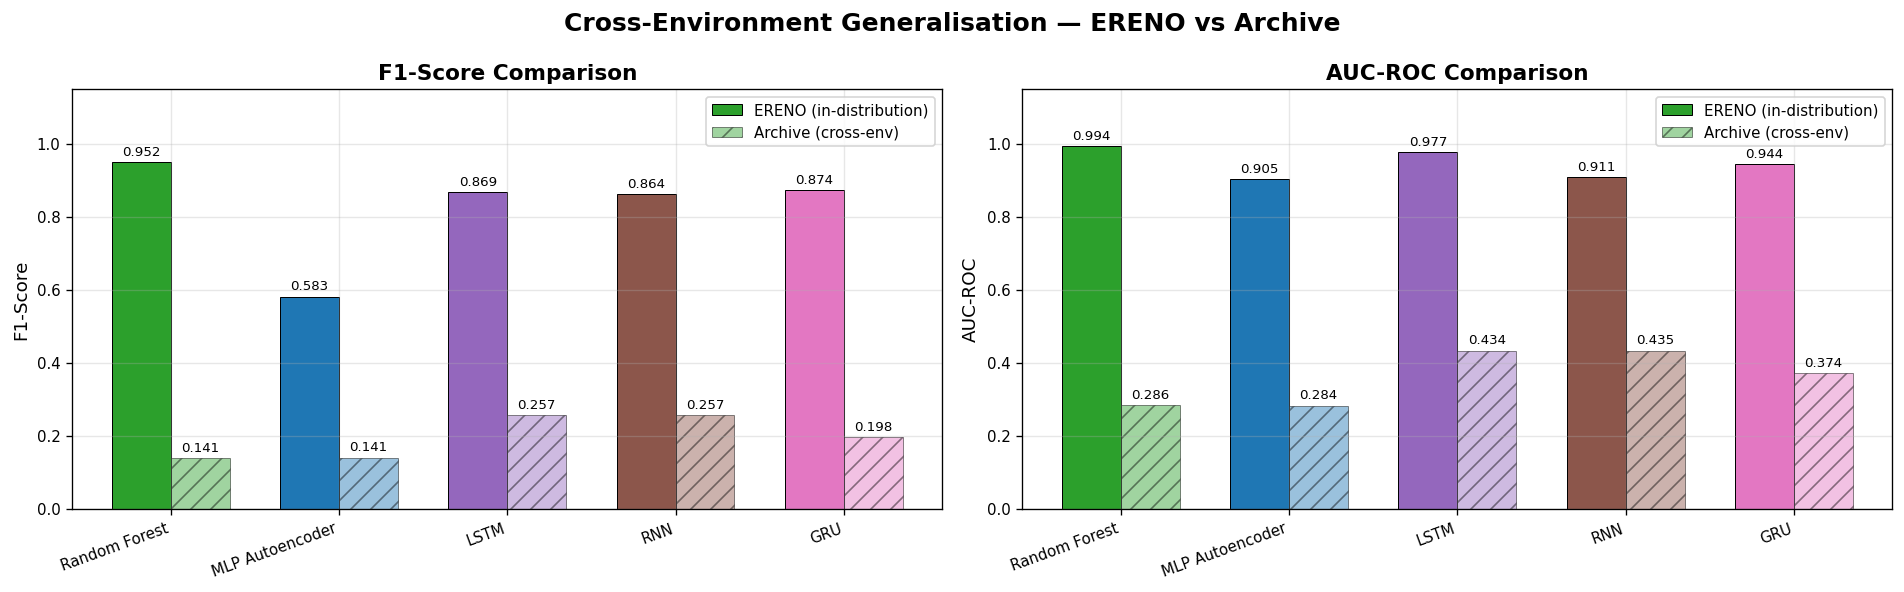

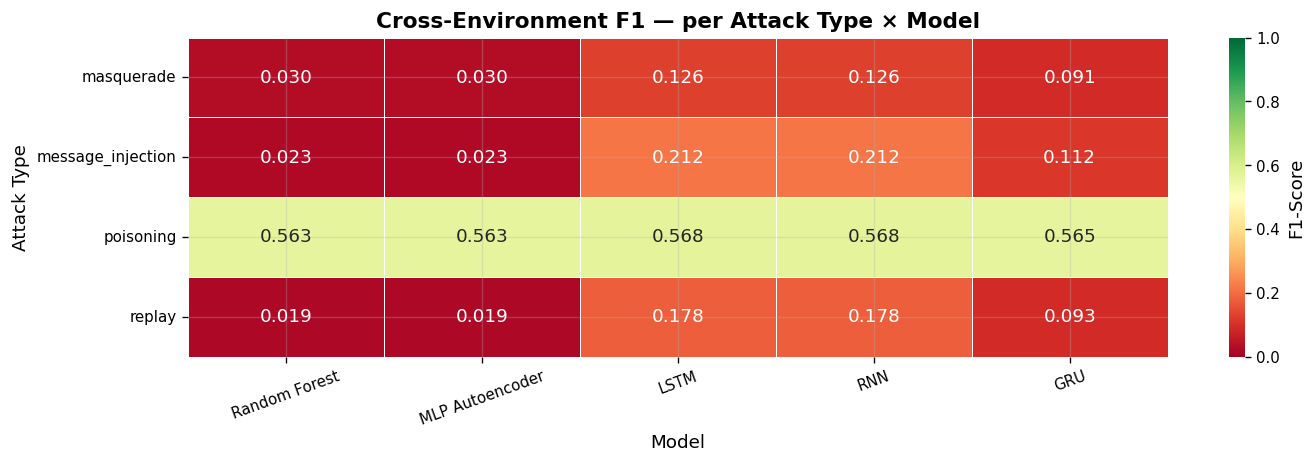

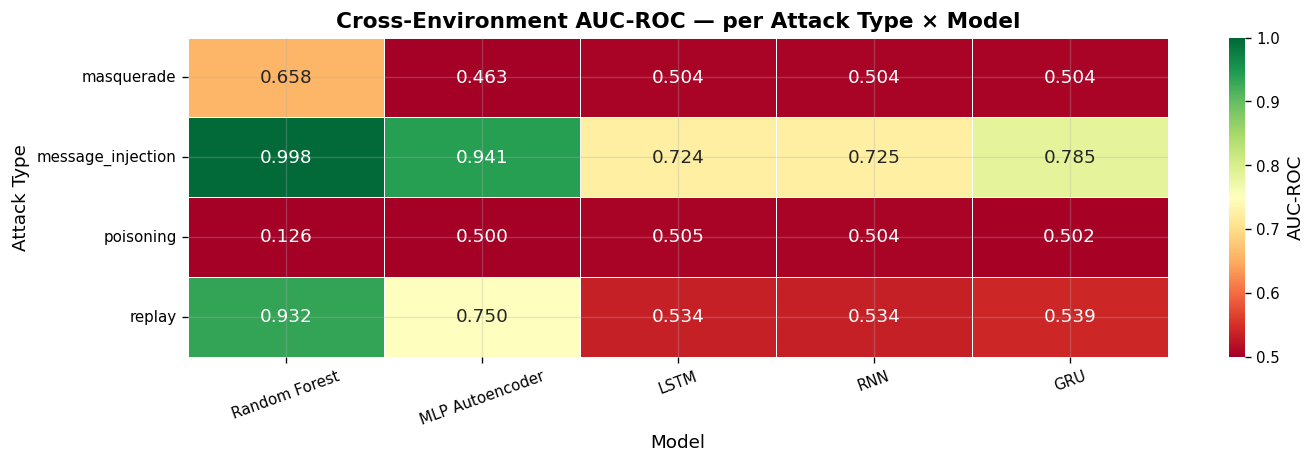

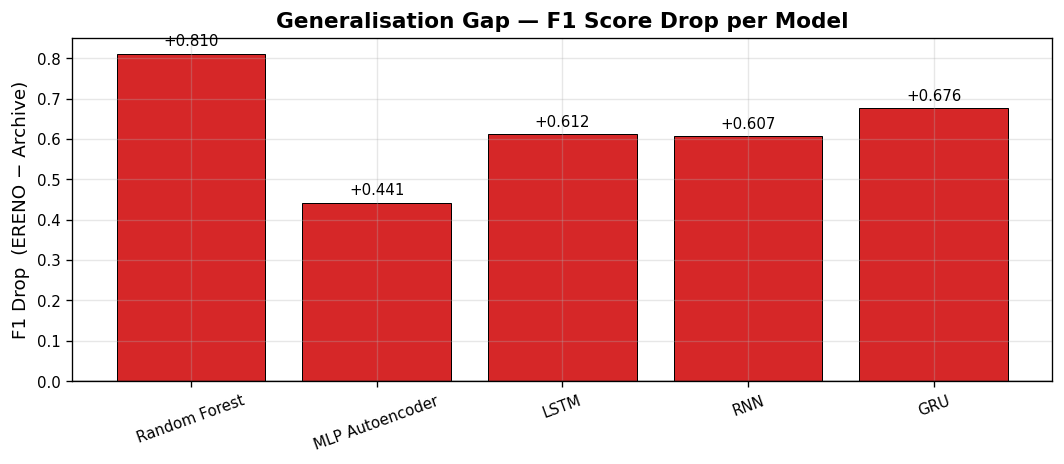

In [73]:
# ══════════════════════════════════════════════════════════════════════════════
# CROSS-ENVIRONMENT GENERALISATION — VISUALISATIONS
# ══════════════════════════════════════════════════════════════════════════════

# ── Chart 1: ERENO vs Archive F1 per model ────────────────────────────────────
ereno_f1 = [results[n]['f1']                            for n in MODEL_ORDER]
arch_f1  = [gen_results[n]['all'].get('f1', 0)          for n in MODEL_ORDER]
ereno_auc= [results[n]['auc_roc']                       for n in MODEL_ORDER]
arch_auc = [gen_results[n]['all'].get('auc_roc', 0)     for n in MODEL_ORDER]

x, w = np.arange(len(MODEL_ORDER)), 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Cross-Environment Generalisation — ERENO vs Archive', fontweight='bold')

b1 = ax1.bar(x - w/2, ereno_f1, w, color=PALETTE, edgecolor='black',
             linewidth=0.6, label='ERENO (in-distribution)')
b2 = ax1.bar(x + w/2, arch_f1,  w, color=PALETTE, edgecolor='black',
             linewidth=0.6, alpha=0.45, hatch='//', label='Archive (cross-env)')
ax1.set_xticks(x); ax1.set_xticklabels(MODEL_ORDER, rotation=20, ha='right')
ax1.set_ylim(0, 1.15); ax1.set_ylabel('F1-Score')
ax1.set_title('F1-Score Comparison')
ax1.bar_label(b1, fmt='%.3f', padding=2, fontsize=8)
ax1.bar_label(b2, fmt='%.3f', padding=2, fontsize=8)
ax1.legend(fontsize=9); ax1.grid(axis='y', alpha=0.3)

b3 = ax2.bar(x - w/2, ereno_auc, w, color=PALETTE, edgecolor='black',
             linewidth=0.6, label='ERENO (in-distribution)')
b4 = ax2.bar(x + w/2, arch_auc,  w, color=PALETTE, edgecolor='black',
             linewidth=0.6, alpha=0.45, hatch='//', label='Archive (cross-env)')
ax2.set_xticks(x); ax2.set_xticklabels(MODEL_ORDER, rotation=20, ha='right')
ax2.set_ylim(0, 1.15); ax2.set_ylabel('AUC-ROC')
ax2.set_title('AUC-ROC Comparison')
ax2.bar_label(b3, fmt='%.3f', padding=2, fontsize=8)
ax2.bar_label(b4, fmt='%.3f', padding=2, fontsize=8)
ax2.legend(fontsize=9); ax2.grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

# ── Chart 2: Per-attack-type F1 heatmap ───────────────────────────────────────
f1_arch_df = pd.DataFrame(
    {name: {atk: gen_results[name].get(atk, {}).get('f1', float('nan'))
            for atk in ARCH_ATTACK_TYPES}
     for name in MODEL_ORDER}
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    f1_arch_df.astype(float), annot=True, fmt='.3f',
    cmap='RdYlGn', vmin=0, vmax=1,
    linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'F1-Score'},
)
ax.set_title('Cross-Environment F1 — per Attack Type × Model', fontweight='bold')
ax.set_xlabel('Model'); ax.set_ylabel('Attack Type')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

# ── Chart 3: Per-attack-type AUC-ROC heatmap ──────────────────────────────────
auc_arch_df = pd.DataFrame(
    {name: {atk: gen_results[name].get(atk, {}).get('auc_roc', float('nan'))
            for atk in ARCH_ATTACK_TYPES}
     for name in MODEL_ORDER}
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    auc_arch_df.astype(float), annot=True, fmt='.3f',
    cmap='RdYlGn', vmin=0.5, vmax=1,
    linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'AUC-ROC'},
)
ax.set_title('Cross-Environment AUC-ROC — per Attack Type × Model', fontweight='bold')
ax.set_xlabel('Model'); ax.set_ylabel('Attack Type')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

# ── Chart 4: F1 drop (ERENO → Archive) per model ─────────────────────────────
drops = [results[n]['f1'] - gen_results[n]['all'].get('f1', 0) for n in MODEL_ORDER]
colors_drop = ['#d62728' if d > 0.1 else '#ff9896' if d > 0 else '#2ca02c'
               for d in drops]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(MODEL_ORDER, drops, color=colors_drop, edgecolor='black', linewidth=0.6)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('F1 Drop  (ERENO − Archive)')
ax.set_title('Generalisation Gap — F1 Score Drop per Model', fontweight='bold')
ax.bar_label(bars, fmt='%+.3f', padding=3, fontsize=9)
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()